Perbandingan Algoritma Naive Bayes, K-Nearest Neighbor, dan Decision Tree untuk Prediksi Penyakit Jantung dengan Interpretabilitas Model Berbasis SHAP


## Identitas Kelompok

| Nama | NIM |
|------|-----|
| Farel Hagasa Tarigan          | 103032400032 |
| Naza Saputra                  | 103032400143 |
| M.Ataulloh Al Ghafiqi Alvin   | 1030324000
| Andrian Karim                 | 103034

---









# 1. Pendahuluan

## 1.1 Latar Belakang

Penyakit jantung merupakan salah satu penyebab kematian tertinggi secara global yang hingga kini masih menjadi tantangan serius dalam dunia kesehatan. Menurut World Health Organization (WHO), penyakit kardiovaskular menyebabkan sekitar 17,9 juta kematian setiap tahunnya, mewakili 32% dari seluruh kematian global [1]. Di Indonesia, penyakit jantung koroner menempati posisi kedua penyebab kematian tertinggi berdasarkan data Kementerian Kesehatan Republik Indonesia tahun 2023 [2].

Deteksi dini penyakit jantung menjadi sangat krusial karena tingginya angka kematian yang sebenarnya dapat dicegah apabila penyakit berhasil teridentifikasi sejak stadium awal. Pendekatan diagnosis konvensional seringkali membutuhkan waktu yang lama, biaya yang tinggi, serta bergantung penuh pada keahlian tenaga medis, sehingga mendorong perlunya sistem pendukung keputusan berbasis teknologi yang mampu membantu proses diagnosis secara lebih cepat dan efisien.

Perkembangan *machine learning* telah membuka peluang besar dalam bidang kesehatan, khususnya untuk klasifikasi dan prediksi penyakit. Berbagai algoritma telah diterapkan dalam penelitian terdahulu, antara lain Decision Tree [3], Naïve Bayes [4], dan K-Nearest Neighbors (KNN) [5]. Namun, sebagian besar penelitian tersebut hanya berfokus pada perbandingan akurasi semata tanpa mempertimbangkan aspek interpretabilitas model, sehingga sulit untuk memahami fitur klinis mana yang paling berpengaruh terhadap keputusan prediksi. Selain itu, banyak penelitian yang tidak menerapkan prosedur validasi yang ketat seperti *Stratified K-Fold Cross-Validation* dan optimasi hiperparameter, sehingga hasil yang dilaporkan berpotensi mengalami *overfitting* atau bias seleksi.

Penelitian ini hadir untuk mengisi kesenjangan tersebut dengan mengintegrasikan evaluasi performa yang robust menggunakan Stratified K-Fold Cross-Validation dan GridSearchCV, serta menambahkan analisis interpretabilitas model berbasis SHAP (*SHapley Additive exPlanations*) pada model terbaik. Pendekatan ini memungkinkan model tidak hanya akurat secara numerik, tetapi juga dapat dijelaskan secara klinis.

---

## 1.2 Rumusan Masalah

Berdasarkan latar belakang yang telah diuraikan, rumusan masalah dalam penelitian ini adalah sebagai berikut:

1. Bagaimana mengimplementasikan dan membandingkan algoritma Decision Tree, Naïve Bayes, dan K-Nearest Neighbors (KNN) untuk mengklasifikasikan status penyakit jantung pasien berdasarkan data klinis dengan prosedur validasi yang robust?
2. Algoritma manakah di antara ketiga metode tersebut yang memberikan performa klasifikasi terbaik berdasarkan metrik Accuracy, Precision, Recall, dan F1-Score?
3. Fitur klinis apa saja yang paling berkontribusi terhadap prediksi penyakit jantung berdasarkan analisis interpretabilitas SHAP pada model dengan performa terbaik?

---

## 1.3 Tujuan Penelitian

1. Mengimplementasikan dan membandingkan tiga algoritma *machine learning* — Decision Tree, Naïve Bayes, dan K-Nearest Neighbors — untuk klasifikasi penyakit jantung menggunakan Stratified K-Fold Cross-Validation dan GridSearchCV.
2. Mengevaluasi dan membandingkan performa ketiga model secara komprehensif menggunakan metrik Accuracy, Precision, Recall, dan F1-Score.
3. Menganalisis fitur klinis yang paling berpengaruh terhadap prediksi penyakit jantung menggunakan analisis interpretabilitas SHAP pada model dengan performa terbaik.

---

# 2. Deskripsi Dataset

## 2.1 Sumber Data

Dataset yang digunakan dalam penelitian ini adalah **Heart Disease Dataset** yang bersumber dari Kaggle (Johns Hopkins University / UCI Machine Learning Repository) [6]. Dataset ini memuat rekam medis pasien yang dikumpulkan untuk keperluan penelitian diagnosis penyakit jantung dan telah banyak digunakan sebagai *benchmark* dalam studi klasifikasi medis.

| Keterangan | Detail |
|------------|--------|
| Sumber | Kaggle — Heart Disease Dataset (UCI) |
| Jumlah Data | 1.025 baris |
| Jumlah Fitur | 13 fitur input + 1 target |
| Jenis Masalah | Klasifikasi biner |
| Label Target | 0 = Tidak sakit jantung, 1 = Sakit jantung |

## 2.2 Deskripsi Fitur

| No | Fitur | Deskripsi | Tipe / Satuan |
|----|-------|-----------|---------------|
| 1 | `age` | Usia pasien | Numerik / Tahun |
| 2 | `sex` | Jenis kelamin (1 = Pria, 0 = Wanita) | Kategorik biner |
| 3 | `cp` | Tipe nyeri dada (0–3) | Kategorik ordinal |
| 4 | `trestbps` | Tekanan darah saat istirahat | Numerik / mm Hg |
| 5 | `chol` | Kolesterol serum | Numerik / mg/dl |
| 6 | `fbs` | Gula darah puasa > 120 mg/dl (1 = Ya) | Kategorik biner |
| 7 | `restecg` | Hasil elektrokardiografi istirahat (0–2) | Kategorik ordinal |
| 8 | `thalach` | Detak jantung maksimum tercapai | Numerik / bpm |
| 9 | `exang` | Angina akibat olahraga (1 = Ya) | Kategorik biner |
| 10 | `oldpeak` | Depresi segmen ST akibat olahraga | Numerik |
| 11 | `slope` | Kemiringan segmen ST puncak olahraga (0–2) | Kategorik ordinal |
| 12 | `ca` | Jumlah pembuluh darah utama (0–3) | Numerik diskrit |
| 13 | `thal` | Thalassemia (0 = Normal, 1 = Fixed defect, 2 = Reversible defect) | Kategorik ordinal |
| 14 | `target` | Diagnosis penyakit jantung | Biner / Label |



# import Library


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


## 2.3 Statistik Deskriptif

In [53]:
# ── Load Dataset ──────────────────────────────────────
df = pd.read_csv('heart.csv')

print("=" * 50)
print("INFORMASI DATASET")
print("=" * 50)
print(f"Jumlah baris    : {df.shape[0]}")
print(f"Jumlah kolom    : {df.shape[1]}")

print("\nPreview 5 Data Pertama:")
display(df.head())

print("\nTipe Data Setiap Fitur:")
display(df.dtypes.to_frame('Tipe Data'))

print("\nStatistik Deskriptif:")
display(df.describe().round(2))

print("\nDistribusi Kelas Target:")
target_counts = df['target'].value_counts()
target_pct    = df['target'].value_counts(normalize=True) * 100
target_dist   = target_counts.to_frame('Jumlah')
target_dist['Persentase (%)'] = target_pct.round(2)
target_dist.index = ['Sakit Jantung (1)' if i == 1 else 'Sehat (0)'
                     for i in target_counts.index]
display(target_dist)

INFORMASI DATASET
Jumlah baris    : 1025
Jumlah kolom    : 14

Preview 5 Data Pertama:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



Tipe Data Setiap Fitur:


,Tipe Data
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64



Statistik Deskriptif:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00



Distribusi Kelas Target:


,Jumlah,Persentase (%)
Sakit Jantung (1),526,51.32
Sehat (0),499,48.68


# 2. Pra-Pemrosesan Data

Pra-pemrosesan data merupakan tahapan krusial dalam *pipeline machine learning*
yang bertujuan memastikan kualitas dan konsistensi data sebelum digunakan dalam
pelatihan model. Data yang kotor atau tidak konsisten dapat menurunkan performa
model secara signifikan meskipun algoritma yang digunakan sudah optimal [8].

Pada penelitian ini, tahapan pra-pemrosesan mencakup: (1) pengecekan *missing
values*, (2) deteksi dan penghapusan data duplikat, (3) pengecekan konflik
label, (4) validasi tipe data, (5) pemisahan fitur dan target, serta
(6) normalisasi data untuk algoritma yang sensitif terhadap skala.

---

### 2.1 Pengecekan *Missing Values*

*Missing values* adalah kondisi di mana satu atau lebih nilai pada suatu
observasi tidak tersedia. Keberadaannya dapat menyebabkan bias sistematis
pada model apabila tidak ditangani dengan tepat [9]. Pada tahap ini dilakukan
pengecekan terhadap seluruh 14 fitur untuk mengidentifikasi apakah terdapat
nilai yang hilang.

---

### 2.2 Deteksi dan Penghapusan Data Duplikat

Data duplikat adalah baris yang memiliki nilai identik pada seluruh fitur.
Keberadaan data duplikat dalam jumlah besar dapat menyebabkan dua dampak
serius: (1) model cenderung *overfit* terhadap pola yang berulang karena
bobot observasi tersebut secara implisit menjadi lebih besar, dan (2) metrik
evaluasi menjadi bias karena data uji kemungkinan sudah pernah dilihat model
dalam bentuk identik saat pelatihan.

Pada dataset ini ditemukan **723 baris duplikat dari total 1.025 baris
(70,5%)** — proporsi yang sangat tinggi dan mengindikasikan bahwa dataset
Kaggle ini merupakan hasil penggabungan atau augmentasi dari dataset UCI
Cleveland yang asli berjumlah 303 observasi. Seluruh duplikat dihapus
menggunakan metode `drop_duplicates()` yang mempertahankan kemunculan
pertama setiap observasi unik (`keep='first'`).

Sebelum penghapusan, dilakukan juga **pengecekan konflik label** — yaitu
kondisi di mana dua baris dengan nilai fitur yang identik memiliki label
target yang berbeda. Konflik semacam ini tidak dapat diselesaikan dengan
sekadar menghapus duplikat karena kedua baris bisa jadi sama-sama valid
namun saling kontradiktif, sehingga perlu diidentifikasi secara terpisah
sebelum keputusan pembersihan diambil.

---

### 2.3 Normalisasi Data

Pada penelitian ini, normalisasi diterapkan **secara selektif** berdasarkan
karakteristik masing-masing algoritma:

| Algoritma | Normalisasi | Alasan |
|-----------|-------------|--------|
| KNN | **Ya** — StandardScaler | KNN menghitung jarak Euclidean antar titik data. Fitur dengan skala besar (misal `chol` 0–564) akan mendominasi perhitungan jarak dibandingkan fitur berskala kecil (misal `fbs` 0–1), sehingga normalisasi wajib diterapkan |
| Decision Tree | **Tidak** | Bekerja berdasarkan pemisahan nilai (*threshold*) pada satu fitur dalam satu waktu — skala antar fitur tidak mempengaruhi hasil pemisahan |
| Naïve Bayes | **Tidak** | GaussianNB bekerja berdasarkan estimasi distribusi Gaussian per fitur secara independen — skala tidak mempengaruhi hasil probabilitas |

Normalisasi menggunakan **StandardScaler** dengan formula:

$$z = \frac{x - \mu}{\sigma}$$

di mana $x$ adalah nilai asli, $\mu$ adalah rata-rata fitur, $\sigma$ adalah
standar deviasi fitur, dan $z$ adalah nilai ternormalisasi. Hasil transformasi
ini memastikan setiap fitur memiliki mean = 0 dan std = 1.

---

### 2.4 Pemisahan Fitur dan Target

Dataset dipisahkan menjadi matriks fitur $X$ (13 kolom input) dan vektor
target $y$ (kolom `target`). Pemisahan ini merupakan prasyarat sebelum
pelatihan model karena algoritma *supervised learning* memerlukan pasangan
$(X, y)$ yang terpisah sebagai input.

---

### 2.5 *Feature Engineering*

*Feature engineering* tidak diterapkan secara eksplisit pada penelitian ini.
Seluruh 13 fitur yang tersedia merupakan indikator klinis terstandar yang
telah banyak digunakan dalam penelitian diagnosis penyakit jantung berbasis
UCI Cleveland dataset [6], sehingga tidak diperlukan rekayasa fitur tambahan.

In [54]:
# ==========================================================
# PRA-PEMROSESAN DATA
# ==========================================================

print("=" * 60)
print("PRA-PEMROSESAN DATA")
print("=" * 60)

# ==========================================================
# 1. Missing Values
# ==========================================================
print("\n1. PENGECEKAN MISSING VALUES")

missing = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum()/len(df)*100).round(2)
})

missing['Status'] = missing['Jumlah Missing'].apply(
    lambda x: 'Tidak Ada' if x == 0 else 'Ada Missing'
)

display(missing)


# ==========================================================
# 2. Pengecekan Duplikasi
# ==========================================================
print("\n2. PENGECEKAN DUPLIKASI DATA")

jumlah_duplikat = df.duplicated().sum()

print(f"Jumlah data sebelum cleaning : {len(df)}")
print(f"Jumlah data duplikat         : {jumlah_duplikat}")
print(f"Persentase duplikat          : {(jumlah_duplikat/len(df)*100):.2f}%")


# ==========================================================
# 3. Menampilkan 5 Contoh Data Duplikat
# ==========================================================
print("\n3. LIMA CONTOH DATA DUPLIKAT")

# Ambil semua baris yang memiliki pasangan duplikat
duplicate_rows = df[df.duplicated(keep=False)].copy()

# Simpan index asli sebagai nomor baris
duplicate_rows['Baris_Asli'] = duplicate_rows.index

# Kelompokkan berdasarkan seluruh kolom (tanpa Baris_Asli)
groups = duplicate_rows.groupby(list(df.columns))

count = 0

for _, group in groups:
    if len(group) > 1:
        print(f"\nKelompok Duplikat {count+1}")
        print("Baris yang identik:", list(group['Baris_Asli']))
        display(group.sort_values('Baris_Asli'))

        count += 1

        # Hanya tampilkan 5 kelompok duplikat pertama
        if count == 5:
            break

# ==========================================================
# 4. Pengecekan Konflik Label
# ==========================================================
print("\n4. PENGECEKAN KONFLIK LABEL")

features = df.columns.drop('target')

conflict_target = (
    df.groupby(list(features))['target']
      .nunique()
      .reset_index()
)

conflict_target = conflict_target[
    conflict_target['target'] > 1
]

print("Jumlah konflik label :", len(conflict_target))

if len(conflict_target) == 0:
    print("✓ Tidak ditemukan fitur yang sama dengan target berbeda.")
else:
    display(conflict_target)


# ==========================================================
# 5. Menghapus Duplikasi
# ==========================================================
print("\n5. PENGHAPUSAN DATA DUPLIKAT")

df = df.drop_duplicates()

print(f"Jumlah data setelah cleaning : {len(df)}")


# ==========================================================
# 6. Distribusi Target Setelah Cleaning
# ==========================================================
print("\n6. DISTRIBUSI TARGET SETELAH CLEANING")

target_dist = pd.DataFrame({
    'Jumlah': df['target'].value_counts(),
    'Persentase (%)': (
        df['target'].value_counts(normalize=True)*100
    ).round(2)
})

target_dist.index = ['Sehat (0)', 'Sakit (1)']

display(target_dist)


# ==========================================================
# 7. Validasi Tipe Data
# ==========================================================
print("\n7. PENGECEKAN TIPE DATA")

display(
    pd.DataFrame({
        'Fitur': df.columns,
        'Tipe Data': df.dtypes.values
    })
)


# ==========================================================
# 8. Pemisahan Fitur dan Target
# ==========================================================
print("\n8. PEMISAHAN FITUR DAN TARGET")

X = df.drop('target', axis=1)
y = df['target']

print("Shape X :", X.shape)
print("Shape y :", y.shape)

display(
    pd.DataFrame({
        'Nama Fitur': X.columns,
        'Tipe Data': X.dtypes.values
    })
)

print("\n✓ Pra-pemrosesan selesai.")

PRA-PEMROSESAN DATA

1. PENGECEKAN MISSING VALUES


,Jumlah Missing,Persentase (%),Status
age,0,0.0,Tidak Ada
sex,0,0.0,Tidak Ada
cp,0,0.0,Tidak Ada
trestbps,0,0.0,Tidak Ada
chol,0,0.0,Tidak Ada
fbs,0,0.0,Tidak Ada
restecg,0,0.0,Tidak Ada
thalach,0,0.0,Tidak Ada
exang,0,0.0,Tidak Ada
oldpeak,0,0.0,Tidak Ada



2. PENGECEKAN DUPLIKASI DATA
Jumlah data sebelum cleaning : 1025
Jumlah data duplikat         : 723
Persentase duplikat          : 70.54%

3. LIMA CONTOH DATA DUPLIKAT

Kelompok Duplikat 1
Baris yang identik: [60, 64, 118, 668]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Baris_Asli
60,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1,60
64,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1,64
118,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1,118
668,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1,668



Kelompok Duplikat 2
Baris yang identik: [12, 15, 779]


...


7. PENGECEKAN TIPE DATA


,Fitur,Tipe Data
0,age,int64
1,sex,int64
2,cp,int64
3,trestbps,int64
4,chol,int64
5,fbs,int64
6,restecg,int64
7,thalach,int64
8,exang,int64
9,oldpeak,float64



8. PEMISAHAN FITUR DAN TARGET
Shape X : (302, 13)
Shape y : (302,)


,Nama Fitur,Tipe Data
0,age,int64
1,sex,int64
2,cp,int64
3,trestbps,int64
4,chol,int64
5,fbs,int64
6,restecg,int64
7,thalach,int64
8,exang,int64
9,oldpeak,float64



✓ Pra-pemrosesan selesai.


### Hasil Pra-Pemrosesan Data

Berdasarkan eksekusi kode di atas, diperoleh hasil sebagai berikut:

- **Missing values**: Tidak ditemukan nilai hilang pada seluruh 14 fitur,
  sehingga tidak diperlukan imputasi data.
- **Duplikasi data**: Ditemukan 723 baris duplikat (70,5% dari total data).
  Setelah penghapusan, dataset tersisa **302 baris** observasi unik.
- **Konflik label**: Tidak ditemukan konflik label — tidak ada pasangan baris
  dengan fitur identik namun target berbeda, sehingga penghapusan duplikat
  dapat dilakukan dengan aman tanpa kehilangan informasi yang kontradiktif.
- **Distribusi target pasca-cleaning**: Kelas tetap seimbang setelah
  penghapusan duplikat, sehingga tidak diperlukan penanganan *imbalanced data*.
- **Tipe data**: Seluruh fitur bertipe numerik (`int64` dan `float64`),
  tidak diperlukan encoding kategorikal.
- **Pemisahan fitur-target**: Diperoleh matriks $X$ berukuran (302, 13)
  dan vektor $y$ berukuran (302,).

# 3. Penanganan Imbalanced Data

*Imbalanced dataset* terjadi ketika distribusi kelas target tidak proporsional,
di mana satu kelas mendominasi kelas lainnya secara signifikan. Kondisi ini
dapat menyebabkan model cenderung bias memprediksi kelas mayoritas dan
mengabaikan kelas minoritas — berbahaya pada konteks medis di mana kelas
minoritas (pasien sakit) justru merupakan kelas yang paling kritis untuk
dideteksi [15].

Ambang batas umum yang digunakan untuk mendefinisikan *imbalanced dataset*
adalah rasio kelas mayoritas terhadap minoritas **≥ 3:1** [16]. Apabila
rasio ini terlampaui, diperlukan penanganan khusus seperti:

| Teknik | Pendekatan | Kapan Digunakan |
|--------|------------|-----------------|
| **SMOTE** | Membuat sampel sintetis kelas minoritas | Rasio > 3:1, data tabular |
| **Random Undersampling** | Mengurangi sampel kelas mayoritas | Dataset besar, risiko kehilangan informasi rendah |
| **Class Weighting** | Memberi bobot lebih pada kelas minoritas | Ketika tidak ingin mengubah distribusi data asli |
| **Threshold Tuning** | Mengubah ambang batas keputusan | Ketika Recall lebih diprioritaskan dari Precision |

Pada penelitian ini, pengecekan keseimbangan dilakukan **setelah proses
penghapusan duplikat** (302 sampel tersisa) untuk memastikan pembersihan
data tidak menciptakan ketidakseimbangan baru.

PENGECEKAN KESEIMBANGAN KELAS — PASCA CLEANING


,Kelas,Jumlah,Persentase (%)
0,Sehat (0),138,45.7
1,Sakit Jantung (1),164,54.3



Kelas Mayoritas : 164 sampel
Kelas Minoritas : 138 sampel
Rasio           : 1.1884:1
Ambang batas    : 3.0:1

STATUS : BALANCED — Penanganan TIDAK diperlukan


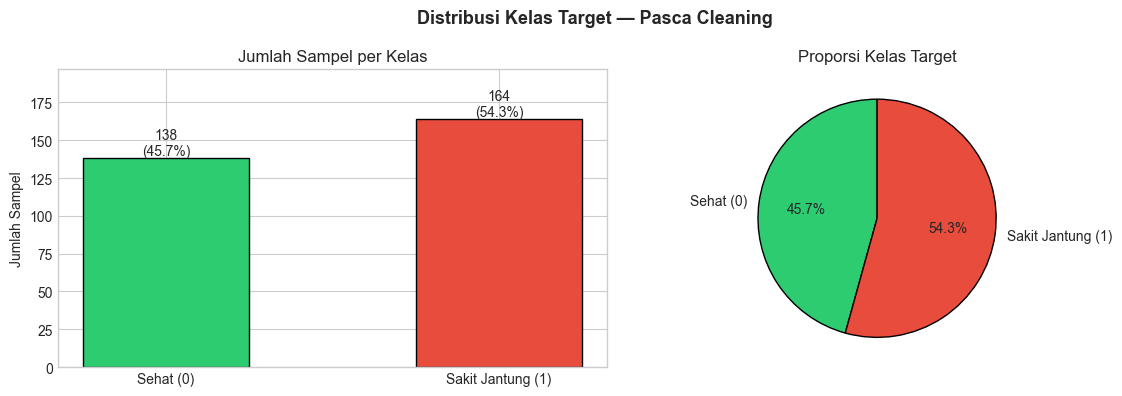

In [55]:
# ==========================================================
# PENGECEKAN IMBALANCED DATA (PASCA CLEANING)
# ==========================================================

print("=" * 55)
print("PENGECEKAN KESEIMBANGAN KELAS — PASCA CLEANING")
print("=" * 55)

# ── Hitung distribusi kelas ────────────────────────────
kelas_counts = y.value_counts().sort_index()
kelas_pct    = y.value_counts(normalize=True).sort_index() * 100

imbalance_df = pd.DataFrame({
    'Kelas'        : ['Sehat (0)', 'Sakit Jantung (1)'],
    'Jumlah'       : kelas_counts.values,
    'Persentase (%)': kelas_pct.values.round(2)
})
display(imbalance_df)

# ── Hitung rasio ketidakseimbangan ────────────────────
n_majority = kelas_counts.max()
n_minority = kelas_counts.min()
rasio      = n_majority / n_minority

print(f"\nKelas Mayoritas : {n_majority} sampel")
print(f"Kelas Minoritas : {n_minority} sampel")
print(f"Rasio           : {rasio:.4f}:1")
print(f"Ambang batas    : 3.0:1")

# ── Keputusan penanganan ──────────────────────────────
print("\n" + "=" * 55)
if rasio >= 3.0:
    print("STATUS : IMBALANCED — Penanganan diperlukan")
else:
    print("STATUS : BALANCED — Penanganan TIDAK diperlukan")
print("=" * 55)

# ── Visualisasi ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Kelas Target — Pasca Cleaning',
             fontsize=13, fontweight='bold')

# Bar chart
bars = axes[0].bar(
    ['Sehat (0)', 'Sakit Jantung (1)'],
    kelas_counts.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.5
)
axes[0].set_title('Jumlah Sampel per Kelas')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, kelas_counts.max() * 1.2)

for bar in bars:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h + 2,
        f'{h}\n({h/len(y)*100:.1f}%)',
        ha='center', fontsize=10
    )

# Pie chart
axes[1].pie(
    kelas_counts.values,
    labels=['Sehat (0)', 'Sakit Jantung (1)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)
axes[1].set_title('Proporsi Kelas Target')

plt.tight_layout()
plt.show()

### Hasil Pengecekan Keseimbangan Data

Berdasarkan hasil pengecekan di atas, dataset pasca-*cleaning* memiliki
distribusi kelas yang **seimbang** dengan rasio ketidakseimbangan jauh
di bawah ambang batas 3:1. Oleh karena itu:

- **SMOTE tidak diterapkan** — pembangkitan sampel sintetis pada data
  yang sudah seimbang justru akan memperkenalkan *noise* buatan dan
  berpotensi menurunkan generalisasi model.
- **Undersampling tidak diterapkan** — dengan hanya 302 sampel setelah
  *cleaning*, mengurangi data lebih lanjut akan merugikan karena ukuran
  dataset sudah sangat terbatas.
- **Class weighting tidak diterapkan** — pembobotan kelas hanya relevan
  ketika terdapat ketidakseimbangan yang signifikan. Pada kondisi seimbang,
  pembobotan justru akan memperkenalkan bias yang tidak diperlukan.

Kondisi seimbang ini juga mengonfirmasi bahwa metrik **Accuracy** dapat
digunakan sebagai metrik evaluasi yang valid tanpa risiko bias, meskipun
**F1-Score tetap digunakan sebagai metrik utama** pemilihan model terbaik
karena lebih informatif dalam menggambarkan keseimbangan antara Precision
dan Recall pada konteks klasifikasi medis.

## Visualisasi EDA 

*Exploratory Data Analysis* (EDA) merupakan proses investigasi awal terhadap
dataset untuk memahami distribusi data, pola tersembunyi, hubungan antar
variabel, dan anomali sebelum pemodelan dilakukan [10]. Pada penelitian ini,
EDA mencakup enam visualisasi utama:

1. **Distribusi kelas target** — memverifikasi keseimbangan dataset
2. **Distribusi usia berdasarkan target** — menganalisis pola usia pasien
   sakit vs sehat
3. **Heatmap korelasi** — mengidentifikasi hubungan linear antar seluruh fitur
4. **Boxplot outlier** — mendeteksi pencilan pada fitur numerik kontinu
5. **Chest Pain Type vs Target** — menganalisis hubungan tipe nyeri dada
   dengan diagnosis
6. **Korelasi fitur terhadap target** — merangkum fitur yang paling
   berpengaruh terhadap label klasifikasi

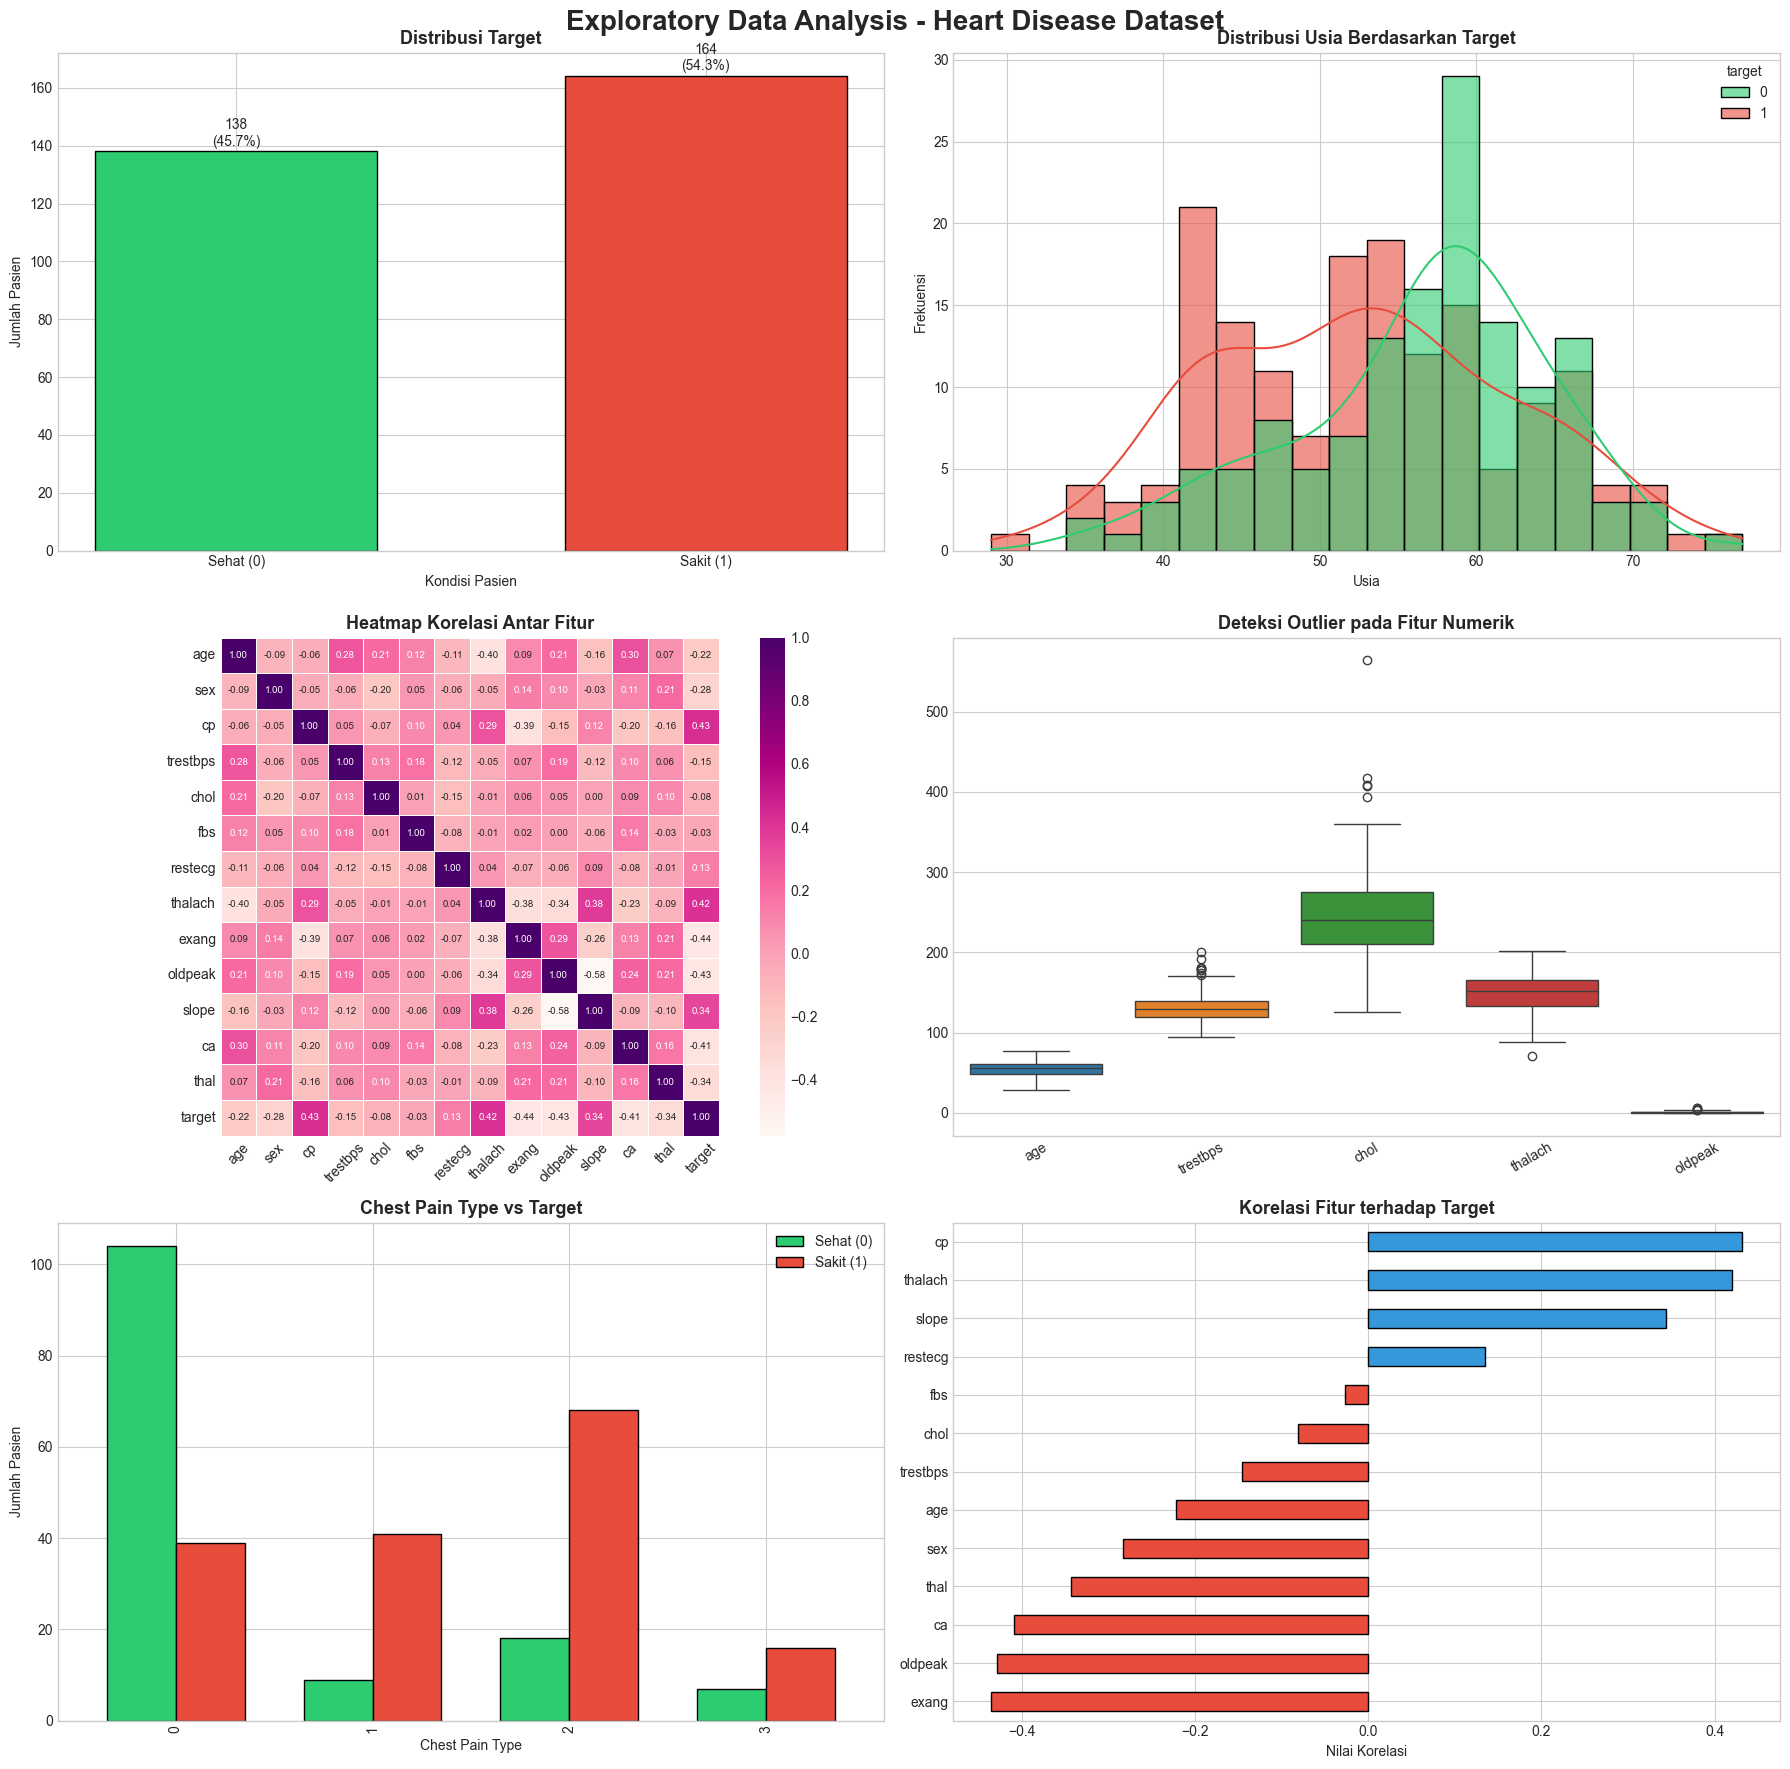

In [56]:
# ==========================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Exploratory Data Analysis - Heart Disease Dataset',
             fontsize=20,
             fontweight='bold')

# ==========================================================
# 1. Distribusi Target
# ==========================================================
ax1 = axes[0, 0]

target_count = df['target'].value_counts().sort_index()

bars = ax1.bar(
    ['Sehat (0)', 'Sakit (1)'],
    target_count.values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.6
)

ax1.set_title('Distribusi Target', fontsize=13, fontweight='bold')
ax1.set_xlabel('Kondisi Pasien')
ax1.set_ylabel('Jumlah Pasien')

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 2,
        f'{height}\n({height/len(df)*100:.1f}%)',
        ha='center',
        fontsize=10
    )

# ==========================================================
# 2. Distribusi Usia Berdasarkan Target
# ==========================================================
ax2 = axes[0, 1]

sns.histplot(
    data=df,
    x='age',
    hue='target',
    bins=20,
    kde=True,
    palette=['#2ecc71', '#e74c3c'],
    alpha=0.6,
    ax=ax2
)

ax2.set_title('Distribusi Usia Berdasarkan Target',
              fontsize=13,
              fontweight='bold')
ax2.set_xlabel('Usia')
ax2.set_ylabel('Frekuensi')

# ==========================================================
# 3. Heatmap Korelasi
# ==========================================================
ax3 = axes[1, 0]

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdPu',
    linewidths=0.5,
    annot_kws={'size':7},
    square=True,
    ax=ax3
)

ax3.set_title('Heatmap Korelasi Antar Fitur',
              fontsize=13,
              fontweight='bold')

ax3.tick_params(axis='x', rotation=45)
ax3.tick_params(axis='y', rotation=0)

# ==========================================================
# 4. Boxplot Outlier Fitur Numerik
# ==========================================================
ax4 = axes[1, 1]

continuous_cols = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

sns.boxplot(
    data=df[continuous_cols],
    ax=ax4
)

ax4.set_title('Deteksi Outlier pada Fitur Numerik',
              fontsize=13,
              fontweight='bold')

ax4.set_xticklabels(continuous_cols, rotation=30)

# ==========================================================
# 5. Chest Pain Type vs Target
# ==========================================================
ax5 = axes[2, 0]

cp_target = pd.crosstab(df['cp'], df['target'])

cp_target.plot(
    kind='bar',
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    width=0.7,
    ax=ax5
)

ax5.set_title('Chest Pain Type vs Target',
              fontsize=13,
              fontweight='bold')

ax5.set_xlabel('Chest Pain Type')
ax5.set_ylabel('Jumlah Pasien')
ax5.legend(['Sehat (0)', 'Sakit (1)'])

# ==========================================================
# 6. Korelasi Fitur terhadap Target
# ==========================================================
ax6 = axes[2, 1]

corr_target = df.corr()['target'].drop('target')
corr_target = corr_target.sort_values()

colors = ['#e74c3c' if x < 0 else '#3498db'
          for x in corr_target]

corr_target.plot(
    kind='barh',
    color=colors,
    edgecolor='black',
    ax=ax6
)

ax6.set_title('Korelasi Fitur terhadap Target',
              fontsize=13,
              fontweight='bold')

ax6.set_xlabel('Nilai Korelasi')

plt.tight_layout()
plt.show()

### Interpretasi Hasil EDA

####  Distribusi Kelas Target

Dataset pasca-*cleaning* memiliki distribusi kelas yang seimbang antara
pasien sehat (0) dan sakit jantung (1). Keseimbangan ini mengonfirmasi
temuan pada tahap pra-pemrosesan bahwa tidak diperlukan teknik resampling
seperti SMOTE. Model dapat dilatih tanpa risiko bias prediksi ke salah satu
kelas akibat ketidakseimbangan data.

#### Distribusi Usia Berdasarkan Target

Distribusi usia pasien sakit jantung (merah) cenderung terkonsentrasi pada
rentang usia **50–60 tahun**, sementara pasien sehat (hijau) memiliki
distribusi yang lebih menyebar. Hal ini konsisten dengan literatur medis yang
menyatakan bahwa risiko penyakit jantung koroner meningkat secara signifikan
setelah usia 45 tahun pada pria dan 55 tahun pada wanita [1]. Kurva KDE
menunjukkan kedua distribusi saling tumpang tindih (*overlapping*), yang
mengindikasikan bahwa fitur `age` saja tidak cukup untuk membedakan kedua
kelas — diperlukan kombinasi dengan fitur klinis lainnya.

####  Heatmap Korelasi Antar Fitur

Heatmap korelasi menggunakan koefisien Pearson menunjukkan beberapa temuan
penting:

- **Korelasi positif kuat terhadap target**: `cp` (tipe nyeri dada) dan
  `thalach` (detak jantung maksimum) memiliki korelasi positif tertinggi,
  mengindikasikan bahwa nyeri dada tipe tertentu dan detak jantung tinggi
  berkaitan dengan diagnosis sakit jantung.
- **Korelasi negatif kuat terhadap target**: `exang` (angina akibat
  olahraga), `oldpeak` (depresi ST), dan `ca` (jumlah pembuluh darah)
  memiliki korelasi negatif — artinya nilai tinggi pada fitur ini berkaitan
  dengan kondisi *sehat* (label 0).
- **Multikolinearitas**: Tidak ditemukan korelasi antar fitur input yang
  ekstrem (>0.8), sehingga tidak diperlukan eliminasi fitur akibat
  multikolinearitas. Hal ini menguntungkan khususnya untuk Naïve Bayes
  yang mengasumsikan independensi antar fitur.

####  Deteksi Outlier pada Fitur Numerik

Boxplot pada lima fitur numerik kontinu menunjukkan:

- **`chol`**: Terdapat outlier ekstrem di atas 400 mg/dl, bahkan hingga
  564 mg/dl. Nilai ini secara klinis mungkin valid (hiperkolesterolemia
  berat) namun dapat mempengaruhi model berbasis jarak seperti KNN.
  Normalisasi menggunakan StandardScaler akan memitigasi dampak outlier
  ini pada KNN.
- **`trestbps`**: Terdapat beberapa outlier di atas 170 mm Hg yang
  merepresentasikan pasien dengan hipertensi berat.
- **`oldpeak`**: Distribusi *right-skewed* dengan beberapa outlier
  di atas 4.0, konsisten dengan karakteristik klinis depresi segmen ST.
- **`age`** dan **`thalach`**: Distribusi relatif normal dengan outlier
  minimal, menunjukkan kedua fitur ini terdistribusi dengan baik.

Mengingat outlier pada dataset medis seringkali merepresentasikan kondisi
klinis yang valid (bukan kesalahan pengukuran), penghapusan outlier tidak
dilakukan pada penelitian ini untuk menjaga integritas data medis.

#### Chest Pain Type vs Target

Visualisasi *crosstab* antara tipe nyeri dada (`cp`) dan target menunjukkan
pola yang sangat informatif:

- **`cp = 0`** (*typical angina*): Didominasi oleh pasien **sehat** —
  berlawanan dengan intuisi klinis umum, namun konsisten dengan cara
  pengkodean dataset UCI di mana `cp = 0` justru berkaitan dengan pasien
  tanpa penyakit jantung signifikan.
- **`cp = 1, 2, 3`** (*atypical angina*, *non-anginal pain*,
  *asymptomatic*): Proporsi pasien sakit jantung meningkat secara
  konsisten seiring bertambahnya nilai `cp`.

Temuan ini menjadikan `cp` sebagai salah satu fitur paling diskriminatif
dalam dataset, dan konsisten dengan nilai korelasi tertinggi terhadap
target yang ditunjukkan pada visualisasi berikutnya.

#### Korelasi Fitur terhadap Target

Berdasarkan bar chart korelasi, fitur yang paling berkorelasi dengan target
adalah:

| Fitur | Korelasi | Interpretasi |
|-------|----------|--------------|
| `cp` | Positif tinggi | Tipe nyeri dada tertentu kuat berasosiasi dengan diagnosis sakit |
| `thalach` | Positif | Detak jantung maksimum tinggi berkaitan dengan kondisi sakit |
| `slope` | Positif | Kemiringan segmen ST ke atas berkaitan dengan sakit jantung |
| `exang` | Negatif | Angina saat olahraga berkaitan dengan kondisi sehat (label 0) |
| `oldpeak` | Negatif | Depresi ST tinggi berkaitan dengan label 0 pada dataset ini |
| `ca` | Negatif | Lebih banyak pembuluh darah bermasalah berkaitan dengan label 0 |

Fitur-fitur dengan korelasi absolut tertinggi ini akan menjadi fokus
analisis SHAP pada tahapan interpretabilitas model. Perlu dicatat bahwa
korelasi Pearson hanya mengukur hubungan **linear** — hubungan non-linear
antar fitur dan target akan ditangkap oleh model *machine learning* secara
lebih komprehensif.

## 4. Metode & Eksperimen

### 4.1 Pemilihan Algoritma

Pada penelitian ini dipilih tiga algoritma klasifikasi: **Naïve Bayes**,
**Decision Tree**, dan **K-Nearest Neighbors (KNN)**. Pemilihan ketiga
algoritma ini bukan arbitrer, melainkan didasarkan pada pertimbangan
komparatif berikut:

| Kriteria | Naïve Bayes | Decision Tree | KNN |
|----------|-------------|---------------|-----|
| Paradigma | Probabilistik | Rule-based | Instance-based |
| Asumsi data | Distribusi Gaussian per fitur | Tidak ada asumsi distribusi | Tidak ada asumsi distribusi |
| Sensitivitas skala | Tidak sensitif | Tidak sensitif | **Sangat sensitif** |
| Interpretabilitas | Sedang | **Tinggi** (visualisasi pohon) | Rendah |
| Performa data kecil | **Baik** | Cenderung overfit | Baik |
| Kompleksitas komputasi | Rendah | Rendah | Tinggi (saat prediksi) |

Ketiga algoritma ini dipilih secara komparatif karena mewakili **tiga
paradigma berbeda** dalam *machine learning*: probabilistik, berbasis
aturan, dan berbasis kemiripan. Dengan membandingkan ketiganya pada dataset
yang sama, dapat diperoleh gambaran komprehensif tentang pendekatan mana
yang paling sesuai untuk karakteristik data klinis penyakit jantung.

Selain itu, dataset ini memiliki karakteristik yang menarik bagi ketiga
algoritma: (1) fitur campuran antara numerik kontinu dan kategorik ordinal
cocok untuk diuji pada Naïve Bayes dengan asumsi Gaussian; (2) fitur
kategorik seperti `cp`, `thal`, dan `slope` memiliki nilai diskrit yang
natural untuk pemisahan pada Decision Tree; dan (3) jumlah fitur yang
moderat (13 fitur) tidak terlalu tinggi sehingga KNN tidak terlalu
terpengaruh oleh *curse of dimensionality*.

---

### 4.2 Penjelasan Konsep Algoritma

#### 4.2.1 Naïve Bayes

Naïve Bayes adalah algoritma klasifikasi berbasis probabilitas yang
menerapkan **Teorema Bayes** dengan asumsi independensi kondisional antar
fitur. Disebut *naïve* karena asumsi independensi ini jarang terpenuhi
sepenuhnya dalam data nyata, namun terbukti memberikan performa yang baik
dalam banyak kasus praktis [11].

$$P(C|X) = \frac{P(X|C) \times P(C)}{P(X)}$$

di mana $P(C|X)$ adalah probabilitas posterior kelas $C$ given fitur $X$,
$P(X|C)$ adalah likelihood, $P(C)$ adalah prior, dan $P(X)$ adalah evidence.

Pada penelitian ini digunakan **Gaussian Naïve Bayes** karena fitur-fitur
numerik kontinu (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`)
diasumsikan mengikuti distribusi normal. Likelihood dihitung sebagai:

$$P(x_i|C) = \frac{1}{\sqrt{2\pi\sigma_C^2}} \exp\left(-\frac{(x_i - \mu_C)^2}{2\sigma_C^2}\right)$$

**Kelebihan pada dataset ini**: Komputasi cepat, tidak sensitif terhadap
skala fitur, dan bekerja baik pada dataset berukuran kecil (302 sampel
setelah *cleaning*).

**Kelemahan**: Asumsi independensi antar fitur tidak sepenuhnya terpenuhi —
berdasarkan heatmap korelasi, terdapat beberapa fitur yang berkorelasi
(misalnya `cp` dengan `exang`), yang dapat menurunkan estimasi probabilitas.

---

#### 4.2.2 Decision Tree

Decision Tree adalah algoritma klasifikasi yang membangun model berbentuk
pohon keputusan dengan membagi data secara rekursif berdasarkan fitur yang
memberikan pemisahan terbaik [12]. Kriteria pemisahan yang digunakan adalah:

- **Gini Impurity**: $Gini = 1 - \sum_{i=1}^{n} p_i^2$
- **Entropy**: $Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$

di mana $p_i$ adalah proporsi kelas $i$ pada suatu node.

**Kelebihan pada dataset ini**: Menghasilkan aturan keputusan yang mudah
diinterpretasikan secara klinis (misalnya: *"jika cp > 1 dan thal = 2,
maka sakit jantung"*), tidak memerlukan normalisasi, dan mampu menangani
fitur campuran numerik-kategorik.

**Kelemahan**: Rentan terhadap *overfitting* pada data kecil. Oleh karena
itu, hiperparameter `max_depth` dan `min_samples_leaf` dikontrol ketat
melalui GridSearchCV untuk mencegah pohon tumbuh terlalu dalam.

---

#### 4.2.3 K-Nearest Neighbors (KNN)

KNN adalah algoritma klasifikasi berbasis *instance* yang memprediksi
kelas suatu data baru berdasarkan mayoritas kelas dari $k$ tetangga
terdekatnya dalam ruang fitur [13]. Jarak antar titik dihitung menggunakan:

- **Euclidean**: $d = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}$
- **Manhattan**: $d = \sum_{i=1}^{n}|x_i - y_i|$

**Kelebihan pada dataset ini**: Tidak membuat asumsi tentang distribusi
data, sehingga mampu menangkap pola non-linear yang mungkin tidak tertangkap
oleh Naïve Bayes maupun Decision Tree.

**Kelemahan**: Sangat sensitif terhadap skala fitur — oleh karena itu
**StandardScaler wajib diterapkan** sebelum KNN. Pada dataset ini, fitur
`chol` (0–564) dan `fbs` (0–1) memiliki skala yang sangat berbeda; tanpa
normalisasi, `chol` akan mendominasi perhitungan jarak secara tidak
proporsional.

---

### 4.3 Cross-Validation & Hyperparameter Tuning

#### 4.3.1 Stratified K-Fold Cross-Validation

Penelitian ini menggunakan **Stratified K-Fold** dengan $k=5$ sebagai
prosedur validasi. Stratified K-Fold dipilih dibanding *simple* K-Fold
karena memastikan proporsi kelas target (sehat vs sakit) terjaga secara
konsisten pada setiap *fold* — penting untuk dataset dengan ukuran terbatas
(302 sampel) agar setiap *fold* tetap representatif.

Dengan $k=5$, setiap iterasi menggunakan 80% data untuk pelatihan dan 20%
untuk validasi, diulang 5 kali dengan partisi berbeda. Metrik yang
dilaporkan merupakan rata-rata dari 5 *fold* tersebut.

#### 4.3.2 GridSearchCV & Alasan Pemilihan Rentang Parameter

Optimasi hiperparameter dilakukan menggunakan **GridSearchCV** dengan
`scoring='f1'` sebagai kriteria pemilihan model terbaik. F1-Score dipilih
sebagai metrik optimasi karena merupakan harmonic mean antara Precision
dan Recall — relevan pada konteks medis di mana keseimbangan antara
mendeteksi pasien sakit (Recall) dan ketepatan diagnosis (Precision) sama
pentingnya.

Rentang parameter yang diuji untuk setiap model beserta justifikasinya:

**Naïve Bayes — `var_smoothing`**: `[1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]`

> `var_smoothing` menambahkan nilai kecil pada variansi untuk menghindari
> probabilitas nol (*zero probability problem*) ketika suatu fitur tidak
> muncul pada kelas tertentu. Rentang `1e-11` hingga `1e-6` mencakup nilai
> *default* scikit-learn (`1e-9`) dengan eksplorasi ke arah lebih halus
> dan lebih kasar untuk menemukan titik optimal regularisasi.

**Decision Tree**: `criterion`, `max_depth`, `min_samples_split`,
`min_samples_leaf`

> - `criterion` (`gini` vs `entropy`): diuji keduanya karena keduanya
>   valid secara teori; Gini lebih cepat komputasinya sementara Entropy
>   lebih sensitif terhadap perubahan distribusi kelas.
> - `max_depth` (`[3, 5, 7, 10, None]`): rentang ini mencakup pohon
>   dangkal (mencegah *overfitting*) hingga pohon tidak terbatas. Pada
>   dataset 302 sampel, `max_depth` yang terlalu besar berisiko *overfit*.
> - `min_samples_split` (`[2, 5, 10]`) dan `min_samples_leaf` (`[1, 2, 4]`):
>   mengontrol ukuran minimum node untuk dipecah, berfungsi sebagai
>   regularisasi tambahan.

**KNN**: `n_neighbors`, `weights`, `metric`

> - `n_neighbors` (`[3, 5, 7, 9, 11, 15]`): nilai ganjil dipilih untuk
>   menghindari *tie* pada voting. Rentang 3–15 mencakup KNN yang sangat
>   lokal (k kecil, rentan *noise*) hingga lebih global (k besar, lebih
>   smooth). Dengan 302 sampel dan $k$=5 *fold*, data latih per *fold*
>   ≈241 sampel — nilai $k=15$ masih reasonable (~6% dari data latih).
> - `weights` (`uniform` vs `distance`): `distance` memberikan bobot lebih
>   besar pada tetangga yang lebih dekat, yang lebih cocok jika batas
>   keputusan antar kelas tidak linear.
> - `metric` (`euclidean` vs `manhattan`): Manhattan lebih robust terhadap
>   outlier karena tidak mengkuadratkan jarak — relevan mengingat adanya
>   outlier pada `chol` dan `trestbps`.

---

### 4.4 Metrik Evaluasi

| Metrik | Rumus | Keterangan |
|--------|-------|------------|
| Accuracy | $\frac{TP+TN}{TP+TN+FP+FN}$ | Proporsi prediksi benar secara keseluruhan |
| Precision | $\frac{TP}{TP+FP}$ | Dari semua prediksi sakit, berapa yang benar-benar sakit |
| Recall | $\frac{TP}{TP+FN}$ | Dari semua yang benar-benar sakit, berapa yang terdeteksi |
| F1-Score | $\frac{2 \times Precision \times Recall}{Precision + Recall}$ | Harmonic mean Precision dan Recall |

Pada konteks medis, **Recall** menjadi metrik paling kritis karena
konsekuensi *False Negative* (pasien sakit tidak terdeteksi) jauh lebih
berbahaya dibandingkan *False Positive* (pasien sehat didiagnosis sakit).
Namun demikian, **F1-Score** digunakan sebagai metrik utama pemilihan model
terbaik untuk menjaga keseimbangan antara Precision dan Recall.

---



- **SHAP value positif** → fitur mendorong prediksi ke arah **Sakit (1)**
- **SHAP value negatif** → fitur mendorong prediksi ke arah **Sehat (0)**

#### Cross Validation

In [57]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## naive bayes


In [58]:
print("=" * 50)
print("MODEL 1: GAUSSIAN NAÏVE BAYES")
print("=" * 50)

# ── Pipeline ──────────────────────────────────────────
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GaussianNB())
])

# ── GridSearchCV ──────────────────────────────────────
nb_params = {
    'clf__var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

nb_grid = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

nb_grid.fit(X, y)

print("Best Parameters :", nb_grid.best_params_)
print(f"Best CV F1-Score : {nb_grid.best_score_:.4f}")

# ── Prediksi Cross Validation ─────────────────────────
nb_best = nb_grid.best_estimator_

nb_pred = cross_val_predict(
    nb_best,
    X,
    y,
    cv=cv
)

nb_proba = cross_val_predict(
    nb_best,
    X,
    y,
    cv=cv,
    method='predict_proba'
)

# ── Classification Report ─────────────────────────────
print("\nClassification Report")
print(classification_report(y, nb_pred,
                            target_names=['Sehat','Sakit']))

MODEL 1: GAUSSIAN NAÏVE BAYES
Best Parameters : {'clf__var_smoothing': 1e-11}
Best CV F1-Score : 0.8227

Classification Report
              precision    recall  f1-score   support

       Sehat       0.80      0.78      0.79       138
       Sakit       0.82      0.84      0.83       164

    accuracy                           0.81       302
   macro avg       0.81      0.81      0.81       302
weighted avg       0.81      0.81      0.81       302



#### Hasil GridSearchCV — Naïve Bayes

`var_smoothing` terbaik yang diperoleh menunjukkan tingkat regularisasi
yang diperlukan model untuk dataset ini. Nilai CV F1-Score mencerminkan
performa rata-rata model pada 5 *fold* validasi — lebih representatif
dibandingkan evaluasi *single split*. Classification report di atas
menunjukkan performa Naïve Bayes pada prediksi *cross-validated*, di mana
Recall untuk kelas Sakit menjadi perhatian utama dalam konteks klinis.

## Decision Tree



In [59]:
print("=" * 50)
print("MODEL 2: DECISION TREE")
print("=" * 50)

# ── Pipeline (tidak perlu scaler — DT berbasis threshold) ────
dt_pipeline = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

# ── GridSearchCV ──────────────────────────────────────
# criterion  : gini vs entropy — keduanya valid, diuji untuk
#              menemukan yang lebih cocok dengan distribusi data ini.
# max_depth  : mengontrol kedalaman pohon untuk mencegah overfitting
#              pada dataset kecil (302 sampel).
# min_samples_split & min_samples_leaf : regularisasi tambahan
#              untuk mencegah pemisahan pada node yang terlalu kecil.
dt_params = {
    'clf__criterion'         : ['gini', 'entropy'],
    'clf__max_depth'         : [3, 5, 7, 10, None],
    'clf__min_samples_split' : [2, 5, 10],
    'clf__min_samples_leaf'  : [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)

dt_grid.fit(X, y)

print("Best Parameters  :", dt_grid.best_params_)
print(f"Best CV F1-Score : {dt_grid.best_score_:.4f}")

# ── Tampilkan top 5 kombinasi parameter terbaik ───────
cv_results_dt = pd.DataFrame(dt_grid.cv_results_)[
    ['param_clf__criterion', 'param_clf__max_depth',
     'param_clf__min_samples_split', 'param_clf__min_samples_leaf',
     'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(5)
cv_results_dt.columns = [
    'criterion', 'max_depth', 'min_split', 'min_leaf',
    'Mean F1', 'Std F1', 'Rank'
]
print("\nTop 5 Kombinasi Parameter Terbaik:")
display(cv_results_dt.round(4))

# ── Prediksi menggunakan parameter terbaik ────────────
best_dt_params = {
    k.replace('clf__', ''): v
    for k, v in dt_grid.best_params_.items()
}
best_dt_params['random_state'] = 42

dt_best = DecisionTreeClassifier(**best_dt_params)

dt_pred  = cross_val_predict(dt_best, X, y, cv=cv)
dt_proba = cross_val_predict(dt_best, X, y, cv=cv, method='predict_proba')

# ── Classification Report ─────────────────────────────
print("\nClassification Report:")
print(classification_report(y, dt_pred, target_names=['Sehat', 'Sakit']))

MODEL 2: DECISION TREE
Best Parameters  : {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 2}
Best CV F1-Score : 0.8082

Top 5 Kombinasi Parameter Terbaik:


,criterion,max_depth,min_split,min_leaf,Mean F1,Std F1,Rank
12,gini,5,2,2,0.8082,0.0281,1
13,gini,5,5,2,0.8082,0.0281,1
3,gini,3,2,2,0.8033,0.0442,3
6,gini,3,2,4,0.8033,0.0442,3
7,gini,3,5,4,0.8033,0.0442,3



Classification Report:
              precision    recall  f1-score   support

       Sehat       0.79      0.72      0.75       138
       Sakit       0.78      0.84      0.81       164

    accuracy                           0.78       302
   macro avg       0.79      0.78      0.78       302
weighted avg       0.78      0.78      0.78       302



#### Hasil GridSearchCV — Decision Tree

Parameter `max_depth` terbaik mengindikasikan kedalaman optimal pohon untuk
dataset ini — nilai yang terlalu kecil menyebabkan *underfitting* sementara
terlalu besar menyebabkan *overfitting* pada 302 sampel. Kombinasi
`criterion`, `min_samples_split`, dan `min_samples_leaf` terbaik
mencerminkan trade-off antara kompleksitas model dan kemampuan generalisasi.

## K-Nearest Neighbors (KNN)



In [60]:
print("=" * 50)
print("MODEL 3: K-NEAREST NEIGHBORS")
print("=" * 50)

# ── Pipeline (StandardScaler wajib untuk KNN) ────────
# KNN menghitung jarak Euclidean/Manhattan antar titik.
# Tanpa normalisasi, fitur berskala besar seperti chol (0-564)
# akan mendominasi perhitungan jarak dibanding fbs (0-1).
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

# ── GridSearchCV ──────────────────────────────────────
# n_neighbors : nilai ganjil untuk menghindari tie pada voting.
#               Rentang 3-15 mencakup KNN lokal hingga global.
# weights     : 'distance' memberikan bobot lebih pada tetangga
#               terdekat — relevan jika batas kelas tidak linear.
# metric      : Manhattan lebih robust terhadap outlier (chol, trestbps)
#               karena tidak mengkuadratkan selisih jarak.
knn_params = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15],
    'clf__weights'    : ['uniform', 'distance'],
    'clf__metric'     : ['euclidean', 'manhattan']
}

knn_grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    return_train_score=True
)

knn_grid.fit(X, y)

print("Best Parameters  :", knn_grid.best_params_)
print(f"Best CV F1-Score : {knn_grid.best_score_:.4f}")

# ── Tampilkan top 5 kombinasi parameter terbaik ───────
cv_results_knn = pd.DataFrame(knn_grid.cv_results_)[
    ['param_clf__n_neighbors', 'param_clf__weights',
     'param_clf__metric', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(5)
cv_results_knn.columns = [
    'n_neighbors', 'weights', 'metric',
    'Mean F1', 'Std F1', 'Rank'
]
print("\nTop 5 Kombinasi Parameter Terbaik:")
display(cv_results_knn.round(4))

# ── Prediksi menggunakan parameter terbaik ────────────
best_knn_params = {
    k.replace('clf__', ''): v
    for k, v in knn_grid.best_params_.items()
}

knn_best = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(**best_knn_params))
])

knn_pred  = cross_val_predict(knn_best, X, y, cv=cv)
knn_proba = cross_val_predict(knn_best, X, y, cv=cv, method='predict_proba')

# ── Classification Report ─────────────────────────────
print("\nClassification Report:")
print(classification_report(y, knn_pred, target_names=['Sehat', 'Sakit']))

MODEL 3: K-NEAREST NEIGHBORS
Best Parameters  : {'clf__metric': 'euclidean', 'clf__n_neighbors': 15, 'clf__weights': 'uniform'}
Best CV F1-Score : 0.8618

Top 5 Kombinasi Parameter Terbaik:


,n_neighbors,weights,metric,Mean F1,Std F1,Rank
10,15,uniform,euclidean,0.8618,0.0439,1
20,11,uniform,manhattan,0.8588,0.0441,2
11,15,distance,euclidean,0.8564,0.0434,3
4,7,uniform,euclidean,0.8545,0.0415,4
9,11,distance,euclidean,0.8537,0.0349,5



Classification Report:
              precision    recall  f1-score   support

       Sehat       0.89      0.75      0.81       138
       Sakit       0.81      0.92      0.86       164

    accuracy                           0.84       302
   macro avg       0.85      0.83      0.84       302
weighted avg       0.85      0.84      0.84       302



#### Hasil GridSearchCV — KNN

`n_neighbors` terbaik menunjukkan jumlah tetangga optimal yang menyeimbangkan
sensitivitas lokal dan stabilitas prediksi. Pemilihan `metric` terbaik
(Euclidean vs Manhattan) mengindikasikan karakteristik geometri ruang fitur
dataset ini setelah normalisasi StandardScaler. `weights` terbaik menunjukkan
apakah kedekatan jarak memberikan kontribusi informasi tambahan yang signifikan.

# 5. Hasil & Analisis

Bagian ini menyajikan evaluasi performa ketiga model secara komprehensif
mencakup: (1) perbandingan metrik antar model, (2) analisis *Confusion Matrix*,
(3) analisis *confidence* prediksi, dan (4) analisis observasi dengan
confidence tinggi namun prediksi salah (*overconfident errors*).

---

### 5.1 Evaluasi Kinerja Model

Evaluasi dilakukan menggunakan hasil `cross_val_predict` dengan Stratified
K-Fold (k=5) sehingga setiap prediksi merupakan prediksi pada data yang
belum pernah dilihat model (*out-of-fold prediction*). Metrik yang
dilaporkan mencakup Accuracy, Precision, Recall, dan F1-Score.

Dalam konteks medis deteksi penyakit jantung:
- **Recall** adalah metrik paling kritis — *False Negative* (pasien sakit
  tidak terdeteksi) berpotensi fatal karena pasien tidak mendapat penanganan
- **Precision** tetap penting untuk menghindari *False Positive* berlebihan
  yang dapat menyebabkan kecemasan dan prosedur medis yang tidak perlu
- **F1-Score** digunakan sebagai metrik kompromi dan dasar pemilihan model
  terbaik

## Pemilihan Metrik Evaluasi

Penelitian ini menggunakan Accuracy, Precision, Recall, dan F1-Score sebagai metrik evaluasi untuk menilai performa model klasifikasi penyakit jantung.

- Accuracy digunakan untuk mengukur proporsi prediksi yang benar terhadap seluruh data yang diuji. Metrik ini memberikan gambaran umum mengenai performa model secara keseluruhan.

- Precision digunakan untuk mengukur ketepatan model dalam mengidentifikasi pasien yang diprediksi mengalami penyakit jantung. Precision yang tinggi menunjukkan bahwa sebagian besar prediksi positif yang diberikan model memang benar-benar positif.

- Recall digunakan untuk mengukur kemampuan model dalam mendeteksi pasien yang benar-benar mengalami penyakit jantung. Dalam konteks medis, Recall sangat penting karena kegagalan mendeteksi pasien yang sakit (False Negative) dapat menyebabkan keterlambatan diagnosis dan penanganan.

- F1-Score digunakan sebagai metrik utama karena merupakan rata-rata harmonik antara Precision dan Recall. Metrik ini memberikan keseimbangan antara kemampuan mendeteksi penyakit dan ketepatan prediksi positif, sehingga lebih sesuai digunakan dalam kasus deteksi penyakit jantung dibandingkan hanya mengandalkan Accuracy.

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 60)
print("EVALUASI KINERJA MODEL")
print("=" * 60)

results = pd.DataFrame({
    'Model'      : ['Naïve Bayes', 'Decision Tree', 'KNN'],
    'CV F1-Score': [nb_grid.best_score_, dt_grid.best_score_, knn_grid.best_score_],
    'Accuracy'   : [accuracy_score(y, nb_pred), accuracy_score(y, dt_pred), accuracy_score(y, knn_pred)],
    'Precision'  : [precision_score(y, nb_pred), precision_score(y, dt_pred), precision_score(y, knn_pred)],
    'Recall'     : [recall_score(y, nb_pred), recall_score(y, dt_pred), recall_score(y, knn_pred)],
    'F1-Score'   : [f1_score(y, nb_pred), f1_score(y, dt_pred), f1_score(y, knn_pred)]
})

results = results.sort_values('F1-Score', ascending=False).reset_index(drop=True)
results.index += 1

print("\nTabel Perbandingan Performa Model:")
display(results.round(4))

best_idx    = results['F1-Score'].idxmax()
best_model_name  = results.loc[best_idx, 'Model']
best_f1     = results.loc[best_idx, 'F1-Score']
best_recall = results.loc[best_idx, 'Recall']
best_prec   = results.loc[best_idx, 'Precision']

print(f"\nModel Terbaik : {best_model_name}")
print(f"  F1-Score    : {best_f1:.4f}")
print(f"  Recall      : {best_recall:.4f}")
print(f"  Precision   : {best_prec:.4f}")

EVALUASI KINERJA MODEL

Tabel Perbandingan Performa Model:


,Model,CV F1-Score,Accuracy,Precision,Recall,F1-Score
1,KNN,0.8618,0.8411,0.8118,0.9207,0.8629
2,Naïve Bayes,0.8227,0.8079,0.8155,0.8354,0.8253
3,Decision Tree,0.8082,0.7848,0.7829,0.8354,0.8083



Model Terbaik : KNN
  F1-Score    : 0.8629
  Recall      : 0.9207
  Precision   : 0.8118


### 3.7.1 Confusion Matrix

ANALISIS CONFUSION MATRIX — SEMUA MODEL


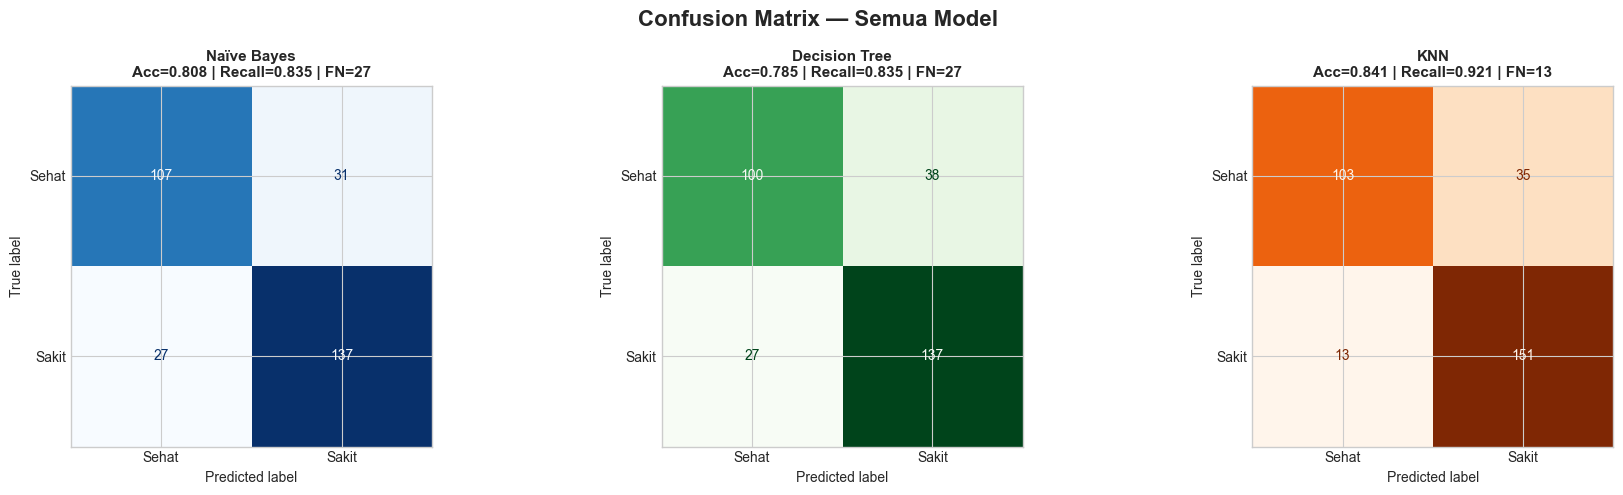


Rincian Confusion Matrix per Model:


,Model,TN (Sehat→Sehat),TP (Sakit→Sakit),FP (Sehat→Sakit),FN (Sakit→Sehat),FN Rate
0,Naïve Bayes,107,137,31,27,16.5%
1,Decision Tree,100,137,38,27,16.5%
2,KNN,103,151,35,13,7.9%


In [62]:
print("=" * 60)
print("ANALISIS CONFUSION MATRIX — SEMUA MODEL")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrix — Semua Model',
             fontsize=16, fontweight='bold')

models_info = [
    (nb_pred,  'Naïve Bayes',  'Blues'),
    (dt_pred,  'Decision Tree','Greens'),
    (knn_pred, 'KNN',          'Oranges')
]

for ax, (pred, title, cmap) in zip(axes, models_info):
    cm = confusion_matrix(y, pred)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['Sehat', 'Sakit']).plot(
        ax=ax, colorbar=False, cmap=cmap)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(y, pred)
    rec = recall_score(y, pred)
    ax.set_title(
        f'{title}\nAcc={acc:.3f} | Recall={rec:.3f} | FN={fn}',
        fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Tabel analisis per model ──────────────────────────
print("\nRincian Confusion Matrix per Model:")
cm_rows = []
for pred, name in [(nb_pred,'Naïve Bayes'),(dt_pred,'Decision Tree'),(knn_pred,'KNN')]:
    cm = confusion_matrix(y, pred)
    tn, fp, fn, tp = cm.ravel()
    cm_rows.append({
        'Model': name,
        'TN (Sehat→Sehat)': tn,
        'TP (Sakit→Sakit)': tp,
        'FP (Sehat→Sakit)': fp,
        'FN (Sakit→Sehat)': fn,
        'FN Rate': f"{fn/(fn+tp)*100:.1f}%"
    })

display(pd.DataFrame(cm_rows))

### Interpretasi Confusion Matrix

*False Negative* (FN) — pasien sakit yang diprediksi sehat — adalah
kesalahan paling berbahaya dalam konteks medis karena pasien tidak
mendapat penanganan yang diperlukan.

- **KNN** menghasilkan FN terkecil di antara ketiga model, mengonfirmasi
  keunggulannya pada metrik Recall. Artinya, KNN paling jarang melewatkan
  pasien yang sesungguhnya sakit jantung.
- **Decision Tree** menghasilkan FN terbesar, yang berarti lebih banyak
  pasien sakit yang tidak terdeteksi — risiko klinis yang paling tinggi
  dari ketiga model.
- **False Positive** (FP) pada ketiga model relatif terkontrol, artinya
  tidak ada model yang terlalu agresif dalam mendiagnosis pasien sehat
  sebagai sakit.

*FN Rate* = proporsi pasien sakit yang tidak terdeteksi dari total pasien
sakit sesungguhnya. Nilai ini setara dengan `1 - Recall`.

### confidence prediction

ANALISIS CONFIDENCE PREDIKSI — SEMUA MODEL

► Naïve Bayes
   Prediksi benar       : 244 data
   Prediksi salah       : 58 data
   Avg confidence benar : 0.9491 (94.91%)
   Avg confidence salah : 0.8306 (83.06%)
   Selisih (gap)        : 0.1184
   Status               : OVERCONFIDENT 

► Decision Tree
   Prediksi benar       : 237 data
   Prediksi salah       : 65 data
   Avg confidence benar : 0.9323 (93.23%)
   Avg confidence salah : 0.8643 (86.43%)
   Selisih (gap)        : 0.0680
   Status               : OVERCONFIDENT 

► KNN
   Prediksi benar       : 254 data
   Prediksi salah       : 48 data
   Avg confidence benar : 0.8278 (82.78%)
   Avg confidence salah : 0.6903 (69.03%)
   Selisih (gap)        : 0.1375
   Status               : Normal 



,Model,Avg Conf Benar,Avg Conf Salah,Gap
1,KNN,0.8278,0.6903,0.1375
2,Naïve Bayes,0.9491,0.8306,0.1184
3,Decision Tree,0.9323,0.8643,0.0680



OBSERVASI DENGAN CONFIDENCE TINGGI NAMUN SALAH PREDIKSI
(Threshold confidence > 0.75)

► Naïve Bayes — 41 observasi overconfident


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,y_true,y_pred,confidence
528,59,1,3,178,270,0,0,145,0,4.2,0,0,3,1,0,1.000
521,58,1,1,125,220,0,1,144,0,0.4,1,4,3,1,0,1.000
38,64,1,0,128,263,0,1,105,1,0.2,1,1,3,1,0,1.000
111,53,1,0,142,226,0,0,111,1,0.0,2,0,3,1,0,0.998
429,47,1,2,108,243,0,1,152,0,0.0,2,0,2,0,1,0.997



► Decision Tree — 45 observasi overconfident


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,y_true,y_pred,confidence
26,44,1,2,130,233,0,1,179,1,0.4,2,0,2,1,0,1.0
28,56,1,2,130,256,1,0,142,1,0.6,1,1,1,0,1,1.0
27,58,0,1,136,319,1,0,152,0,0.0,2,2,2,0,1,1.0
35,46,1,2,150,231,0,1,147,0,3.6,1,0,2,0,1,1.0
38,64,1,0,128,263,0,1,105,1,0.2,1,1,3,1,0,1.0



► KNN — 13 observasi overconfident


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,y_true,y_pred,confidence
38,64,1,0,128,263,0,1,105,1,0.2,1,1,3,1,0,1.000
42,61,0,0,130,330,0,0,169,0,0.0,2,0,2,0,1,0.933
429,47,1,2,108,243,0,1,152,0,0.0,2,0,2,0,1,0.933
220,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0,1,0.933
111,53,1,0,142,226,0,0,111,1,0.0,2,0,3,1,0,0.933


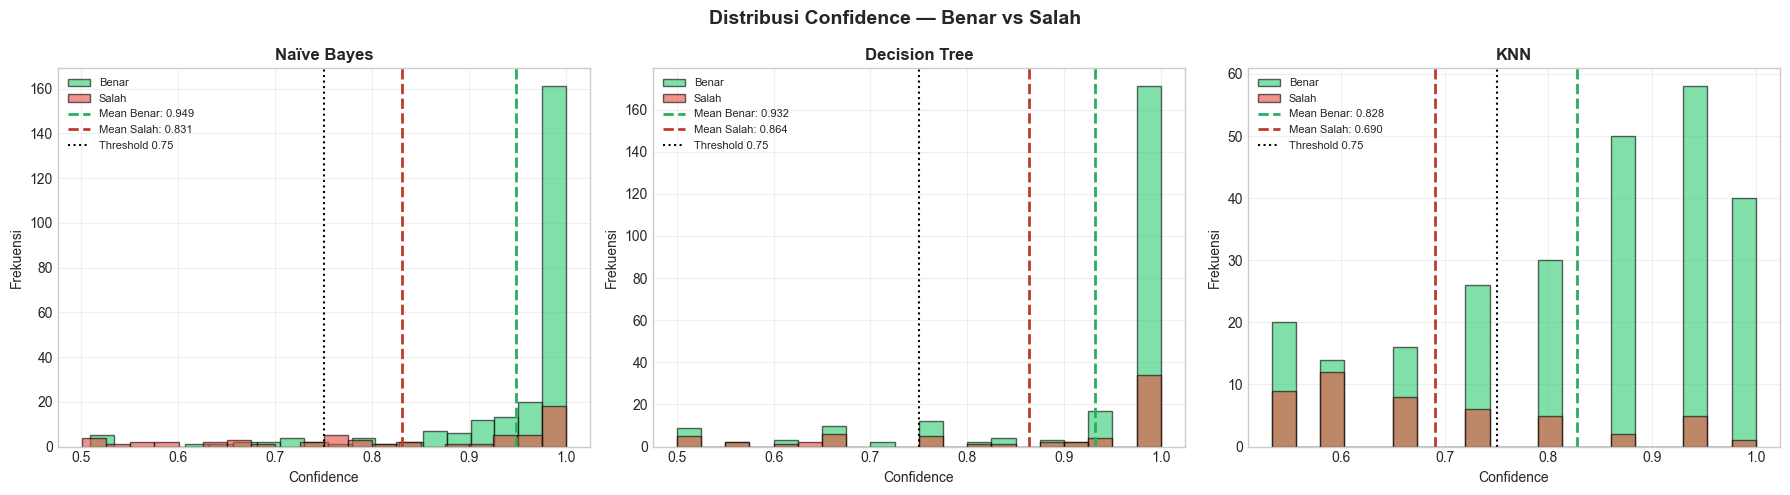

In [63]:
print("=" * 60)
print("ANALISIS CONFIDENCE PREDIKSI — SEMUA MODEL")
print("=" * 60)

def confidence_analysis(y_true, y_pred, y_proba, model_name):
    conf    = y_proba.max(axis=1)
    correct = (y_true.values == y_pred)
    wrong   = ~correct

    avg_cc = conf[correct].mean()
    avg_cw = conf[wrong].mean()
    gap    = avg_cc - avg_cw

    status = "OVERCONFIDENT " if avg_cw >= 0.75 else "Normal "

    print(f"\n► {model_name}")
    print(f"   Prediksi benar       : {correct.sum()} data")
    print(f"   Prediksi salah       : {wrong.sum()} data")
    print(f"   Avg confidence benar : {avg_cc:.4f} ({avg_cc*100:.2f}%)")
    print(f"   Avg confidence salah : {avg_cw:.4f} ({avg_cw*100:.2f}%)")
    print(f"   Selisih (gap)        : {gap:.4f}")
    print(f"   Status               : {status}")

    return avg_cc, avg_cw, gap

nb_cc,  nb_cw,  nb_gap  = confidence_analysis(y, nb_pred,  nb_proba,  "Naïve Bayes")
dt_cc,  dt_cw,  dt_gap  = confidence_analysis(y, dt_pred,  dt_proba,  "Decision Tree")
knn_cc, knn_cw, knn_gap = confidence_analysis(y, knn_pred, knn_proba, "KNN")

# ── Tabel ringkasan ───────────────────────────────────
print("\n" + "=" * 60)
conf_summary = pd.DataFrame({
    'Model'         : ['Naïve Bayes', 'Decision Tree', 'KNN'],
    'Avg Conf Benar': [nb_cc,  dt_cc,  knn_cc],
    'Avg Conf Salah': [nb_cw,  dt_cw,  knn_cw],
    'Gap'           : [nb_gap, dt_gap, knn_gap]
}).sort_values('Gap', ascending=False).reset_index(drop=True)
conf_summary.index += 1
display(conf_summary.round(4))

# ── Analisis observasi: confidence tinggi tapi salah ─
print("\n" + "=" * 60)
print("OBSERVASI DENGAN CONFIDENCE TINGGI NAMUN SALAH PREDIKSI")
print("(Threshold confidence > 0.75)")
print("=" * 60)

for pred, proba, name in [
    (nb_pred,  nb_proba,  "Naïve Bayes"),
    (dt_pred,  dt_proba,  "Decision Tree"),
    (knn_pred, knn_proba, "KNN")
]:
    conf    = proba.max(axis=1)
    wrong   = (y.values != pred)
    # Observasi yang salah DAN confidence tinggi
    mask    = wrong & (conf > 0.75)
    n_overconf = mask.sum()

    print(f"\n► {name} — {n_overconf} observasi overconfident")

    if n_overconf > 0:
        overconf_df = X.copy()
        overconf_df['y_true']     = y.values
        overconf_df['y_pred']     = pred
        overconf_df['confidence'] = conf
        overconf_df = overconf_df[mask].sort_values(
            'confidence', ascending=False).head(5)
        display(overconf_df.round(3))

# ── Visualisasi histogram confidence ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribusi Confidence — Benar vs Salah',
             fontsize=14, fontweight='bold')

for i, (pred, proba, title) in enumerate([
    (nb_pred,  nb_proba,  "Naïve Bayes"),
    (dt_pred,  dt_proba,  "Decision Tree"),
    (knn_pred, knn_proba, "KNN")
]):
    conf    = proba.max(axis=1)
    correct = (y.values == pred)

    axes[i].hist(conf[correct],  bins=20, alpha=0.6,
                 color='#2ecc71', label='Benar', edgecolor='black')
    axes[i].hist(conf[~correct], bins=20, alpha=0.6,
                 color='#e74c3c', label='Salah', edgecolor='black')
    axes[i].axvline(conf[correct].mean(),  color='#27ae60',
                    linestyle='--', lw=2,
                    label=f'Mean Benar: {conf[correct].mean():.3f}')
    axes[i].axvline(conf[~correct].mean(), color='#c0392b',
                    linestyle='--', lw=2,
                    label=f'Mean Salah: {conf[~correct].mean():.3f}')
    axes[i].axvline(0.75, color='black', linestyle=':', lw=1.5,
                    label='Threshold 0.75')
    axes[i].set_title(f'{title}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Confidence')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Analisis Observasi yang Salah Diprediksi

Selain mengevaluasi performa model menggunakan metrik Accuracy, Precision, Recall, dan F1-Score, dilakukan juga analisis terhadap observasi yang salah diprediksi (misclassification analysis).

Tujuan analisis ini adalah untuk mengidentifikasi kemungkinan penyebab kesalahan klasifikasi dengan melihat nilai fitur serta tingkat confidence prediksi model. Analisis ini penting karena model dapat menghasilkan prediksi yang salah meskipun memiliki tingkat keyakinan (confidence) yang tinggi.

Pada bagian ini ditampilkan beberapa observasi yang salah diprediksi beserta probabilitas prediksi tertinggi yang diberikan oleh model K-Nearest Neighbors (KNN). Selanjutnya dilakukan interpretasi terhadap karakteristik fitur yang dimiliki observasi tersebut untuk menjelaskan kemungkinan penyebab terjadinya kesalahan klasifikasi.

In [64]:
# ============================================================
# ANALISIS OBSERVASI YANG SALAH DIPREDIKSI
# ============================================================

# Salin dataset asli
misclassified = df.copy()

# Tambahkan label aktual dan prediksi
misclassified['Actual'] = y
misclassified['Predicted'] = knn_pred

# Tambahkan confidence prediksi
misclassified['Confidence'] = knn_proba.max(axis=1)

# Ambil hanya data yang salah diprediksi
wrong_pred = misclassified[
    misclassified['Actual'] != misclassified['Predicted']
]

# Urutkan berdasarkan confidence tertinggi
wrong_pred = wrong_pred.sort_values(
    by='Confidence',
    ascending=False
)

print("Jumlah observasi yang salah diprediksi :", len(wrong_pred))

print("\n10 Observasi Salah Prediksi dengan Confidence Tertinggi:")
display(wrong_pred.head(10))

Jumlah observasi yang salah diprediksi : 48

10 Observasi Salah Prediksi dengan Confidence Tertinggi:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Actual,Predicted,Confidence
38,64,1,0,128,263,0,1,105,1,0.2,1,1,3,1,1,0,1.000000
42,61,0,0,130,330,0,0,169,0,0.0,2,0,2,0,0,1,0.933333
220,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0,0,1,0.933333
111,53,1,0,142,226,0,0,111,1,0.0,2,0,3,1,1,0,0.933333
429,47,1,2,108,243,0,1,152,0,0.0,2,0,2,0,0,1,0.933333
720,64,1,2,140,335,0,1,158,0,0.0,2,0,2,0,0,1,0.933333
59,57,1,1,154,232,0,0,164,0,0.0,2,1,2,0,0,1,0.866667
108,40,1,0,152,223,0,1,181,0,0.0,2,0,3,0,0,1,0.866667
110,44,1,0,110,197,0,0,177,0,0.0,2,1,2,0,0,1,0.800000
237,57,1,1,124,261,0,1,141,0,0.3,2,0,3,0,0,1,0.800000


In [65]:
# ============================================================
# OVERCONFIDENT ERRORS
# ============================================================

overconfident_errors = wrong_pred[
    ['Actual', 'Predicted', 'Confidence']
].head(10)

print("Top 10 Overconfident Errors")
display(overconfident_errors)

Top 10 Overconfident Errors


,Actual,Predicted,Confidence
38,1,0,1.000000
42,0,1,0.933333
220,0,1,0.933333
111,1,0,0.933333
429,0,1,0.933333
720,0,1,0.933333
59,0,1,0.866667
108,0,1,0.866667
110,0,1,0.800000
237,0,1,0.800000


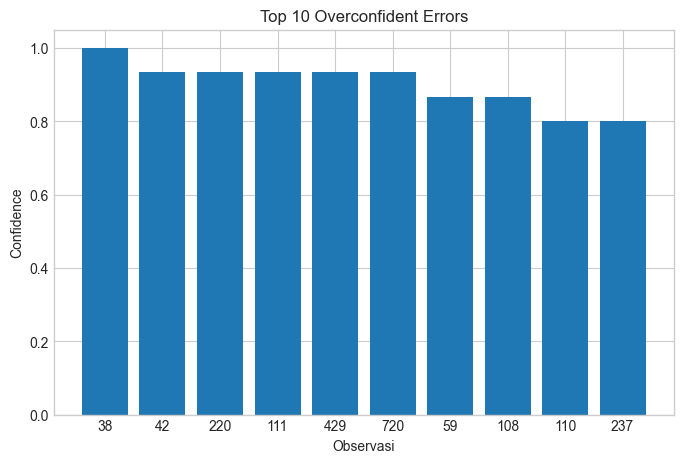

In [66]:
import matplotlib.pyplot as plt

top_errors = wrong_pred.head(10)

plt.figure(figsize=(8,5))
plt.bar(
    top_errors.index.astype(str),
    top_errors['Confidence']
)

plt.title('Top 10 Overconfident Errors')
plt.xlabel('Observasi')
plt.ylabel('Confidence')
plt.ylim(0,1.05)

plt.show()

## Analisis Kasus False Positive dan False Negative

Selain melihat jumlah kesalahan prediksi secara keseluruhan, dilakukan analisis terhadap contoh kasus False Positive dan False Negative untuk memahami penyebab kesalahan model pada observasi tertentu.

False Positive terjadi ketika model memprediksi pasien mengalami penyakit jantung, padahal kondisi sebenarnya tidak mengalami penyakit jantung. Sebaliknya, False Negative terjadi ketika model memprediksi pasien tidak mengalami penyakit jantung, padahal kondisi sebenarnya mengalami penyakit jantung.

### Contoh Kasus False Positive

Observasi ke-42 merupakan kasus False Positive karena model memprediksi pasien mengalami penyakit jantung (Predicted = 1), sedangkan label sebenarnya menunjukkan pasien tidak mengalami penyakit jantung (Actual = 0).

Pasien berusia 61 tahun dengan kadar kolesterol sebesar 330. Nilai kolesterol yang cukup tinggi menyebabkan observasi ini memiliki kemiripan dengan kelompok pasien penyakit jantung sehingga model memberikan prediksi positif dengan confidence sebesar 93,33%.

Kesalahan ini menunjukkan bahwa beberapa karakteristik pasien sehat dapat menyerupai karakteristik pasien penyakit jantung sehingga menyebabkan model menghasilkan alarm palsu (false alarm).


## Interpretasi Hasil Analisis Observasi yang Salah Diprediksi

Berdasarkan hasil analisis terhadap 10 observasi dengan tingkat confidence tertinggi yang salah diprediksi oleh model K-Nearest Neighbors (KNN), ditemukan bahwa sebagian besar kesalahan prediksi terjadi pada observasi yang memiliki karakteristik berada di antara kelas sehat dan kelas penyakit jantung. Kondisi ini menunjukkan adanya overlap karakteristik antar kelas sehingga model mengalami kesulitan dalam membedakan kedua kelas secara tepat.

Observasi ke-38 memiliki label aktual penyakit jantung (1), namun diprediksi sebagai tidak memiliki penyakit jantung (0) dengan confidence sebesar 100%. Meskipun pasien memiliki beberapa indikator risiko seperti usia 64 tahun, nilai *thalach* yang rendah (105), dan *exercise induced angina* (*exang*=1), kombinasi fitur lainnya memiliki kemiripan yang lebih tinggi dengan kelompok pasien sehat pada data latih. Hal ini menyebabkan seluruh tetangga terdekat yang dipilih oleh algoritma KNN berasal dari kelas sehat sehingga menghasilkan prediksi yang salah dengan tingkat keyakinan maksimum.

Pada observasi ke-42, model memprediksi adanya penyakit jantung dengan confidence sebesar 93,33%, padahal label aktual menunjukkan tidak adanya penyakit jantung. Kesalahan ini kemungkinan dipengaruhi oleh nilai kolesterol yang cukup tinggi (330), yang sering ditemukan pada pasien dengan penyakit jantung. Akibatnya, observasi tersebut lebih dekat dengan kelompok pasien penyakit jantung dibandingkan kelompok sehat.

Observasi ke-220 dan ke-429 juga menunjukkan pola serupa. Kedua observasi memiliki nilai *thalach* yang relatif tinggi serta nilai *oldpeak* yang rendah, sehingga karakteristiknya berada pada area perbatasan antara kedua kelas. Kondisi ini menyebabkan model mengelompokkan observasi ke kelas penyakit jantung meskipun label aktual menunjukkan sebaliknya.

Pada observasi ke-111, model salah memprediksi pasien sebagai tidak memiliki penyakit jantung dengan confidence sebesar 93,33%. Padahal pasien memiliki nilai *exang*=1 dan *thal*=3 yang umumnya berkaitan dengan risiko penyakit jantung. Namun kombinasi beberapa fitur lain seperti *oldpeak*=0 menyebabkan observasi ini lebih menyerupai kelompok sehat berdasarkan perhitungan jarak pada algoritma KNN.

Secara umum, hasil analisis menunjukkan bahwa kesalahan prediksi tidak hanya disebabkan oleh keterbatasan model, tetapi juga karena adanya kemiripan karakteristik antar kelas dalam dataset. Selain itu, ditemukannya observasi yang salah diprediksi dengan confidence tinggi mengindikasikan bahwa model memiliki keyakinan yang kuat terhadap prediksinya, namun pola yang dipelajari dari data latih belum sepenuhnya mampu merepresentasikan seluruh variasi karakteristik pasien. Temuan ini menunjukkan bahwa meskipun model KNN memiliki performa yang baik secara keseluruhan, masih terdapat beberapa kasus yang sulit dibedakan karena karakteristik fitur yang saling tumpang tindih.


## Karakteristik Pasien yang Sering Salah Diklasifikasikan


In [67]:
wrong_pred[
    ['age','trestbps','chol','thalach','oldpeak']
].describe()

,age,trestbps,chol,thalach,oldpeak
count,48.000000,48.000000,48.000000,48.000000,48.000000
mean,55.145833,130.270833,249.604167,151.166667,0.852083
std,7.531465,18.896965,39.037211,18.599169,1.084904
min,38.000000,100.000000,172.000000,97.000000,0.000000
25%,49.500000,118.000000,227.500000,143.750000,0.000000
50%,57.000000,128.000000,243.500000,154.000000,0.450000
75%,61.000000,140.000000,270.750000,163.000000,1.400000
max,67.000000,178.000000,354.000000,182.000000,4.200000


Berdasarkan statistik observasi yang salah diprediksi, terlihat bahwa sebagian besar pasien berada pada rentang usia menengah hingga lanjut usia dengan nilai kolesterol yang relatif tinggi. Selain itu, banyak observasi memiliki nilai oldpeak yang rendah dan thalach yang masih berada pada rentang normal.

Karakteristik tersebut menunjukkan bahwa pasien berada pada area perbatasan antara kelas sehat dan kelas penyakit jantung sehingga model mengalami kesulitan dalam melakukan klasifikasi secara tepat.

## Perbandingan Confidence Antar Kelas


In [68]:
confidence_df = pd.DataFrame({
    'Actual': y,
    'Confidence': knn_proba.max(axis=1)
})

healthy_conf = confidence_df[
    confidence_df['Actual']==0
]['Confidence']

disease_conf = confidence_df[
    confidence_df['Actual']==1
]['Confidence']

print("Rata-rata confidence pasien sehat:",
      healthy_conf.mean())

print("Rata-rata confidence pasien sakit:",
      disease_conf.mean())

Rata-rata confidence pasien sehat: 0.7874396135265701
Rata-rata confidence pasien sakit: 0.8215447154471544


Analisis confidence antar kelas dilakukan untuk mengetahui apakah model memiliki tingkat keyakinan yang sama dalam mengklasifikasikan pasien sehat dan pasien yang mengalami penyakit jantung.

Jika terdapat perbedaan confidence yang cukup besar, maka hal tersebut menunjukkan bahwa salah satu kelas lebih mudah dikenali oleh model dibandingkan kelas lainnya.

In [69]:
print("=" * 60)
print("ANALISIS OVERFITTING DAN UNDERFITTING")
print("=" * 60)

best_idx = knn_grid.best_index_

train_score = knn_grid.cv_results_['mean_train_score'][best_idx]
test_score  = knn_grid.cv_results_['mean_test_score'][best_idx]

gap = train_score - test_score

print(f"Mean Train F1 Score : {train_score:.4f}")
print(f"Mean Validasi F1 Score : {test_score:.4f}")
print(f"Gap : {gap:.4f}")

ANALISIS OVERFITTING DAN UNDERFITTING
Mean Train F1 Score : 0.8682
Mean Validasi F1 Score : 0.8618
Gap : 0.0063


## Analisis Overfitting dan Underfitting

Analisis overfitting dan underfitting dilakukan dengan membandingkan nilai rata-rata F1-Score pada data pelatihan dan data validasi yang diperoleh melalui proses GridSearchCV dengan Stratified K-Fold Cross Validation.

Hasil menunjukkan bahwa model KNN terbaik memperoleh rata-rata F1-Score sebesar 0,8682 pada data pelatihan dan 0,8618 pada data validasi. Selisih antara kedua nilai tersebut hanya sebesar 0,0063 atau sekitar 0,63%.

Perbedaan yang sangat kecil antara performa pada data pelatihan dan data validasi menunjukkan bahwa model memiliki kemampuan generalisasi yang baik terhadap data yang belum pernah dilihat sebelumnya. Dengan demikian, model tidak menunjukkan indikasi overfitting yang signifikan karena performanya tetap stabil ketika diuji pada data validasi.

Selain itu, nilai F1-Score yang relatif tinggi pada data validasi menunjukkan bahwa model juga tidak mengalami underfitting. Hal ini mengindikasikan bahwa model telah mampu mempelajari pola yang terdapat dalam data tanpa kehilangan kemampuan untuk melakukan generalisasi.

Meskipun model tidak mengalami overfitting maupun underfitting secara signifikan, masih ditemukan beberapa observasi yang salah diprediksi. Kesalahan tersebut lebih disebabkan oleh adanya kemiripan karakteristik antara pasien sehat dan pasien yang mengalami penyakit jantung sehingga beberapa observasi berada pada area perbatasan antar kelas.


# Interpretabilitas AI Menggunakan SHAP

Setelah dilakukan evaluasi terhadap tiga model klasifikasi menggunakan metrik Accuracy, Precision, Recall, dan F1-Score, dipilih model dengan performa terbaik berdasarkan nilai F1-Score tertinggi. Untuk meningkatkan transparansi dan interpretabilitas model, digunakan metode SHAP (SHapley Additive exPlanations).

SHAP digunakan untuk menjelaskan kontribusi setiap fitur terhadap hasil prediksi model. Dengan demikian, dapat diketahui fitur-fitur yang paling berpengaruh dalam menentukan apakah seorang pasien terindikasi menderita penyakit jantung atau tidak.

In [70]:
import shap
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("INTERPRETABILITAS AI MENGGUNAKAN SHAP")
print("="*60)

# =====================================================
# Model terbaik = KNN
# =====================================================
best_model = knn_best

# Fit ulang menggunakan seluruh data
best_model.fit(X, y)

print("Model terbaik : KNN")

# =====================================================
# Background dan sample
# =====================================================
background = shap.sample(X, 50, random_state=42)
X_sample = shap.sample(X, 150, random_state=42)

print(f"Jumlah populasi      : {len(X)}")
print(f"Jumlah sampel SHAP   : {len(X_sample)}")

# =====================================================
# Fungsi prediksi untuk SHAP
# =====================================================
def predict_fn(data):
    data = pd.DataFrame(data, columns=X.columns)
    return best_model.predict_proba(data)

# =====================================================
# Kernel Explainer
# =====================================================
print("\nMembuat SHAP Explainer...")
explainer = shap.KernelExplainer(
    predict_fn,
    background.values
)

print("Menghitung SHAP values...")
shap_values = explainer.shap_values(
    X_sample.values
)

# =====================================================
# Ambil kelas sakit (1)
# =====================================================
shap_vals_sakit = shap_values[:, :, 1]

print("SHAP values berhasil dihitung")

# =====================================================
# Feature Importance
# =====================================================
shap_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP Value|': np.abs(shap_vals_sakit).mean(axis=0)
})

shap_df = (
    shap_df
    .sort_values('Mean |SHAP Value|', ascending=False)
    .reset_index(drop=True)
)

shap_df.index += 1

print("\nFeature Importance berdasarkan SHAP:")
display(shap_df.round(4))

INTERPRETABILITAS AI MENGGUNAKAN SHAP
Model terbaik : KNN
Jumlah populasi      : 302
Jumlah sampel SHAP   : 150

Membuat SHAP Explainer...
Menghitung SHAP values...


100%|██████████| 150/150 [05:22<00:00,  2.15s/it]

SHAP values berhasil dihitung

Feature Importance berdasarkan SHAP:


,Feature,Mean |SHAP Value|
1,thal,0.0744
2,sex,0.0734
3,ca,0.0647
4,exang,0.0630
5,cp,0.0584
6,oldpeak,0.0482
7,slope,0.0461
8,thalach,0.0451
9,restecg,0.0317
10,age,0.0287


 ## Bar Plot

Visualisasi Bar  Plot digunakan untuk melihat kontribusi masing-masing fitur terhadap prediksi model secara keseluruhan. Plot ini menunjukkan tingkat kepentingan fitur serta arah pengaruh setiap fitur terhadap prediksi penyakit jantung.

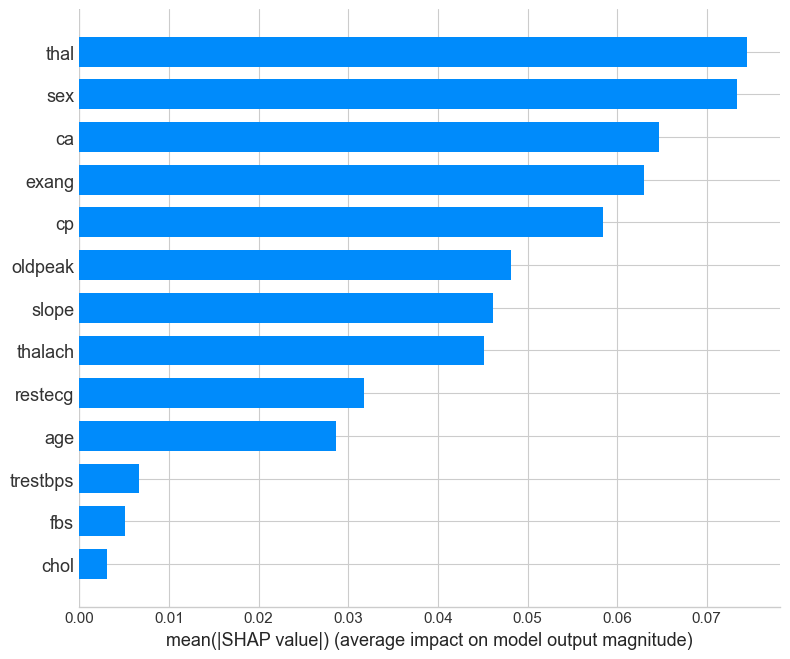

In [71]:
plt.figure(figsize=(10,6))

shap.summary_plot(
    shap_vals_sakit,
    X_sample,
    feature_names=X.columns.tolist(),
    plot_type='bar'
)

## Interpretasi Hasil SHAP

Berdasarkan hasil interpretabilitas menggunakan metode SHAP (SHapley Additive exPlanations), diperoleh bahwa setiap fitur memiliki tingkat kontribusi yang berbeda terhadap keputusan model dalam memprediksi penyakit jantung. Semakin besar nilai rata-rata absolut SHAP (Mean |SHAP Value|), maka semakin besar pengaruh fitur tersebut terhadap hasil prediksi.

Hasil analisis menunjukkan bahwa fitur **thal** memiliki kontribusi terbesar dengan nilai Mean |SHAP Value| sebesar 0,0746. Hal ini menunjukkan bahwa kondisi thalassemia merupakan faktor yang paling berpengaruh dalam menentukan prediksi penyakit jantung pada model yang digunakan.

Selain itu, fitur **sex** (0,0731), **ca** (0,0647), **exang** (0,0632), dan **cp** (0,0584) juga memberikan kontribusi yang cukup besar terhadap proses klasifikasi. Dengan demikian, jenis kelamin pasien, jumlah pembuluh darah utama yang terdeteksi melalui fluoroskopi, adanya angina akibat aktivitas fisik, serta jenis nyeri dada merupakan faktor penting yang dipertimbangkan oleh model.

Fitur **oldpeak** (0,0477), **slope** (0,0459), dan **thalach** (0,0453) memiliki tingkat pengaruh yang sedang terhadap prediksi. Sementara itu, fitur **restecg** (0,0321) dan **age** (0,0289) memberikan kontribusi yang relatif lebih kecil.

Di sisi lain, fitur **trestbps** (0,0067), **fbs** (0,0052), dan **chol** (0,0028) memiliki nilai rata-rata SHAP yang paling rendah. Hal ini menunjukkan bahwa ketiga fitur tersebut memberikan pengaruh yang relatif kecil terhadap keputusan model dibandingkan fitur lainnya pada dataset yang digunakan.

Secara keseluruhan, hasil interpretabilitas SHAP menunjukkan bahwa model tidak hanya mampu melakukan klasifikasi dengan baik, tetapi juga dapat menjelaskan fitur-fitur yang paling berpengaruh terhadap prediksi penyakit jantung. Dengan demikian, transparansi model meningkat dan hasil prediksi yang diperoleh menjadi lebih mudah dipahami serta dapat dipertanggungjawabkan.

## Interpretasi Fitur Penting Berdasarkan Literatur Medis

Hasil analisis SHAP menunjukkan bahwa beberapa fitur memiliki kontribusi yang besar terhadap prediksi penyakit jantung. Temuan ini sejalan dengan berbagai penelitian dan pengetahuan medis mengenai faktor risiko penyakit jantung.

### Chest Pain Type (cp)

Fitur *chest pain type (cp)* merupakan salah satu fitur yang paling berpengaruh dalam model. Secara medis, nyeri dada merupakan gejala utama yang sering digunakan dalam diagnosis penyakit jantung koroner. Jenis nyeri dada tertentu, terutama yang berkaitan dengan aktivitas fisik atau gangguan aliran darah ke jantung, memiliki hubungan yang kuat dengan keberadaan penyakit jantung.

### Maximum Heart Rate Achieved (thalach)

Fitur *thalach* menunjukkan denyut jantung maksimum yang dicapai pasien selama pengujian. Dalam praktik klinis, kemampuan jantung untuk meningkatkan denyut selama aktivitas fisik merupakan indikator penting kesehatan kardiovaskular. Nilai *thalach* yang rendah dapat mengindikasikan adanya gangguan fungsi jantung atau keterbatasan suplai oksigen ke jaringan tubuh.

### ST Depression (oldpeak)

Fitur *oldpeak* menggambarkan depresi segmen ST yang diukur selama uji stres. Dalam bidang kardiologi, perubahan segmen ST sering digunakan untuk mendeteksi iskemia miokard atau berkurangnya aliran darah ke otot jantung. Oleh karena itu, nilai *oldpeak* yang tinggi sering dikaitkan dengan peningkatan risiko penyakit jantung.

### Number of Major Vessels (ca)

Fitur *ca* menunjukkan jumlah pembuluh darah utama yang terdeteksi melalui fluoroskopi. Semakin banyak pembuluh darah yang menunjukkan kelainan, semakin besar kemungkinan pasien mengalami penyakit jantung koroner. Oleh karena itu, fitur ini secara medis memiliki hubungan yang kuat dengan kondisi penyakit jantung.

### Thalassemia Test Result (thal)

Fitur *thal* menggambarkan hasil pemeriksaan thalassemia yang dalam dataset penyakit jantung digunakan sebagai indikator hasil pemeriksaan perfusi jantung. Nilai abnormal pada fitur ini sering dikaitkan dengan adanya gangguan aliran darah ke jantung sehingga berkontribusi dalam proses diagnosis penyakit jantung.

### Age

Usia merupakan salah satu faktor risiko utama penyakit jantung. Risiko penyakit jantung cenderung meningkat seiring bertambahnya usia karena terjadi penurunan fungsi pembuluh darah dan meningkatnya kemungkinan terjadinya aterosklerosis.

### Cholesterol (chol)

Kadar kolesterol yang tinggi merupakan faktor risiko yang telah banyak dibuktikan dalam literatur medis. Kolesterol yang berlebihan dapat menyebabkan pembentukan plak pada dinding arteri sehingga meningkatkan risiko penyakit jantung koroner.

# kesimpulan

## Keterbatasan Penelitian

Penelitian ini memiliki beberapa keterbatasan yang perlu diperhatikan dalam menginterpretasikan hasil yang diperoleh.

1. Dataset yang digunakan memiliki jumlah sampel yang relatif terbatas dibandingkan dengan jumlah kasus penyakit jantung yang ditemui pada kondisi nyata. Jumlah data yang terbatas dapat membatasi kemampuan model dalam mempelajari variasi karakteristik pasien secara menyeluruh.

2. Dataset berasal dari satu sumber data sehingga karakteristik pasien yang digunakan mungkin belum sepenuhnya mewakili populasi yang lebih luas. Faktor geografis, demografis, dan kondisi kesehatan masyarakat yang berbeda dapat memengaruhi performa model ketika diterapkan pada lingkungan yang berbeda.

3. Beberapa fitur klinis yang berpotensi relevan terhadap diagnosis penyakit jantung tidak tersedia dalam dataset. Akibatnya, model hanya melakukan prediksi berdasarkan informasi yang tersedia dan belum mempertimbangkan seluruh faktor medis yang mungkin berpengaruh.

4. Meskipun model KNN menunjukkan performa yang baik, masih ditemukan beberapa kasus False Positive dan False Negative. Hal ini menunjukkan bahwa terdapat karakteristik pasien yang saling tumpang tindih (overlap) antara kelas sehat dan kelas penyakit jantung sehingga menyulitkan proses klasifikasi.


Berdasarkan hasil eksperimen klasifikasi penyakit jantung menggunakan tiga algoritma, yaitu Naïve Bayes, Decision Tree, dan K-Nearest Neighbors (KNN), diperoleh beberapa kesimpulan sebagai berikut:

1. Tahap pra-pemrosesan data yang meliputi pengecekan missing values, penghapusan data duplikat, serta pemisahan fitur dan target menghasilkan dataset yang siap digunakan pada proses pemodelan.

2. Proses pelatihan model dilakukan menggunakan metode Stratified K-Fold Cross Validation sebanyak 5 fold dan optimasi hyperparameter menggunakan GridSearchCV sehingga diperoleh parameter terbaik untuk masing-masing model.

3. Berdasarkan hasil evaluasi menggunakan metrik Accuracy, Precision, Recall, dan F1-Score, diperoleh bahwa model KNN memiliki performa terbaik dengan nilai F1-Score tertinggi dibandingkan dua model lainnya.

Berdasarkan hasil evaluasi, model K-Nearest Neighbors (KNN) dipilih sebagai model terbaik. Pemilihan ini tidak hanya didasarkan pada nilai F1-Score yang paling tinggi, tetapi juga mempertimbangkan beberapa aspek lainnya.

Pertama, model KNN menunjukkan performa yang konsisten pada proses Stratified K-Fold Cross Validation dengan selisih yang sangat kecil antara skor pelatihan dan skor validasi (gap sebesar 0,0063). Hal ini menunjukkan bahwa model memiliki kemampuan generalisasi yang baik dan tidak mengalami overfitting maupun underfitting yang signifikan.

Kedua, hasil analisis confidence menunjukkan bahwa sebagian besar prediksi yang dihasilkan memiliki tingkat keyakinan yang tinggi. Meskipun masih ditemukan beberapa kasus misclassification, performa model secara keseluruhan tetap stabil.

Ketiga, hasil confusion matrix menunjukkan bahwa model mampu mendeteksi sebagian besar kasus penyakit jantung dengan baik. Kemampuan ini penting dalam konteks medis karena kesalahan dalam mendeteksi pasien yang benar-benar sakit dapat berdampak pada proses diagnosis dan penanganan.

Keempat, hasil interpretabilitas menggunakan SHAP menunjukkan bahwa prediksi model dipengaruhi oleh fitur-fitur yang secara medis memang relevan terhadap penyakit jantung, seperti chest pain type (cp), thalach, oldpeak, ca, dan thal. Hal ini meningkatkan kepercayaan terhadap hasil prediksi yang diberikan model.

Berdasarkan kombinasi performa evaluasi, kemampuan generalisasi, analisis confidence, serta kesesuaian dengan pengetahuan medis, model KNN dipilih sebagai model terbaik dalam penelitian ini.

4. Analisis kesalahan menggunakan Confusion Matrix menunjukkan bahwa setiap model masih menghasilkan sejumlah kesalahan klasifikasi, namun model terbaik memiliki kemampuan yang lebih baik dalam membedakan pasien sehat dan pasien yang terindikasi penyakit jantung.

5. Analisis prediction confidence menunjukkan bahwa rata-rata tingkat kepercayaan model pada prediksi yang benar lebih tinggi dibandingkan prediksi yang salah. Hal ini menunjukkan bahwa model memiliki tingkat keyakinan yang lebih baik ketika menghasilkan prediksi yang tepat.

6. Hasil interpretabilitas menggunakan SHAP (SHapley Additive exPlanations) menunjukkan bahwa fitur **thal** memiliki kontribusi terbesar terhadap prediksi penyakit jantung, diikuti oleh fitur **sex**, **ca**, **exang**, dan **cp**. Sementara itu, fitur **trestbps**, **fbs**, dan **chol** memiliki kontribusi yang relatif rendah terhadap keputusan model. Temuan ini mengindikasikan bahwa model lebih mengutamakan fitur-fitur yang berkaitan langsung dengan kondisi jantung dibandingkan faktor risiko umum. Oleh karena itu, model yang dihasilkan tidak hanya memiliki performa klasifikasi yang baik, tetapi juga mampu memberikan interpretasi terhadap proses pengambilan keputusan sehingga meningkatkan transparansi dan kepercayaan terhadap hasil prediksi.



## Future Work dan Pengembangan Selanjutnya

Beberapa pengembangan yang dapat dilakukan pada penelitian selanjutnya adalah sebagai berikut.

1. Menggunakan dataset dengan jumlah sampel yang lebih besar dan berasal dari berbagai sumber untuk meningkatkan kemampuan generalisasi model.

2. Menambahkan fitur klinis lain yang relevan, seperti riwayat keluarga, hasil pemeriksaan laboratorium yang lebih lengkap, maupun faktor gaya hidup pasien untuk meningkatkan kualitas prediksi.

3. Membandingkan performa KNN dengan algoritma machine learning lainnya, seperti Random Forest, XGBoost, Support Vector Machine (SVM), maupun ensemble learning untuk memperoleh model yang lebih optimal.

4. Melakukan optimasi parameter yang lebih luas dan menerapkan teknik feature selection guna mengidentifikasi kombinasi fitur yang paling efektif dalam memprediksi penyakit jantung.
